In [2]:
import pandas as pd
print(pd.__version__)

3.0.2


(35011, 10)
timestamp    datetime64[us]
RT_price            float64
DA_price            float64
spread              float64
temp                float64
wind                float64
cloud                 int64
load                float64
gas                 float64
solar               float64
dtype: object
timestamp    0
RT_price     0
DA_price     0
spread       0
temp         0
wind         0
cloud        0
load         0
gas          0
solar        0
dtype: int64
            timestamp  RT_price  DA_price  spread  temp  wind  cloud  \
0 2022-01-03 00:00:00   34.8450     30.84  4.0050   2.5  15.4      0   
1 2022-01-03 01:00:00   34.7625     30.36  4.4025   2.2  14.5      0   
2 2022-01-03 02:00:00   35.5100     29.95  5.5600   1.8  13.2      0   
3 2022-01-03 03:00:00   36.1725     29.60  6.5725   1.4  12.8      0   
4 2022-01-03 04:00:00   36.8775     30.50  6.3775   0.9  11.1      0   

           load   gas  solar  
0  48446.754417  3.82    0.0  
1  48196.133326  3.82    0.0  
2  48

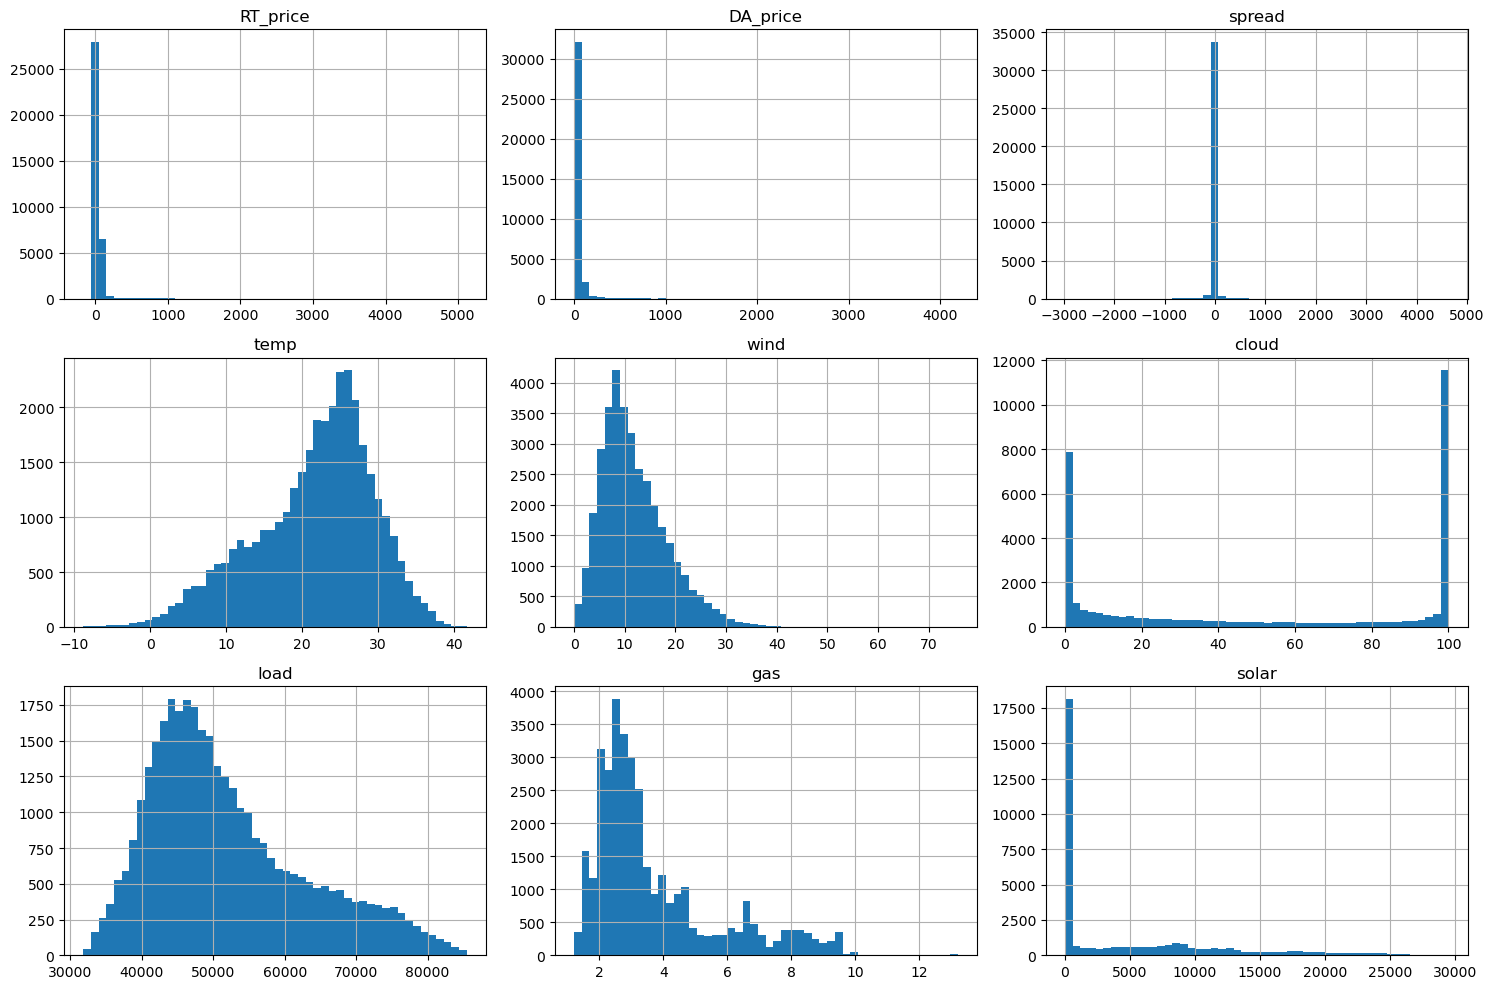

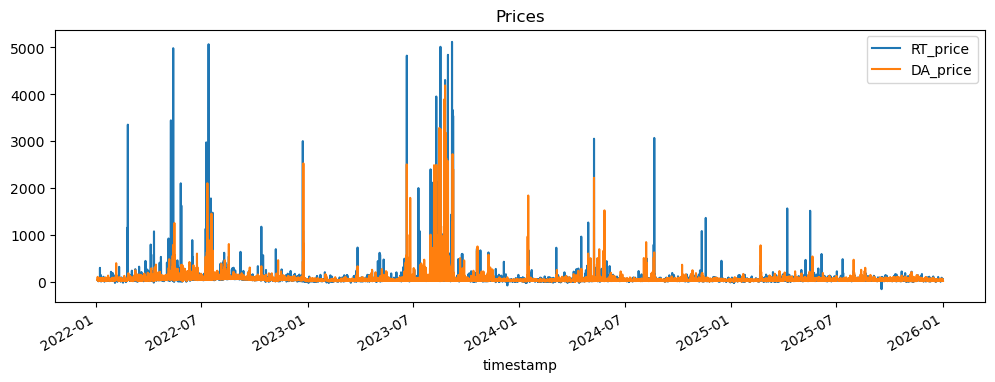

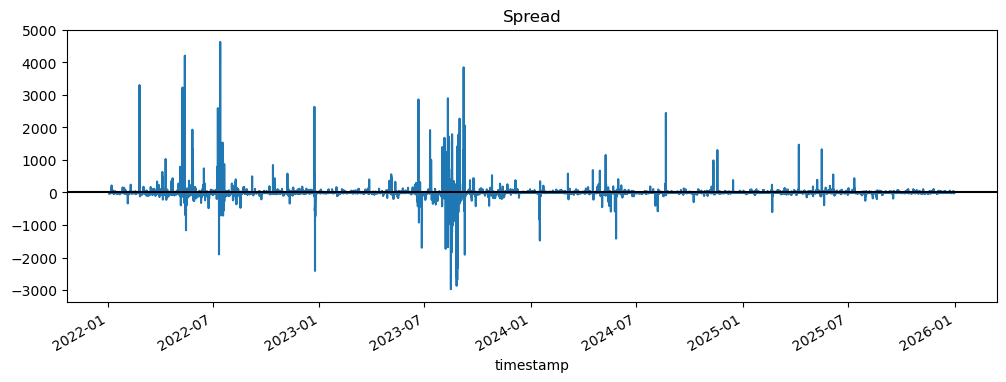

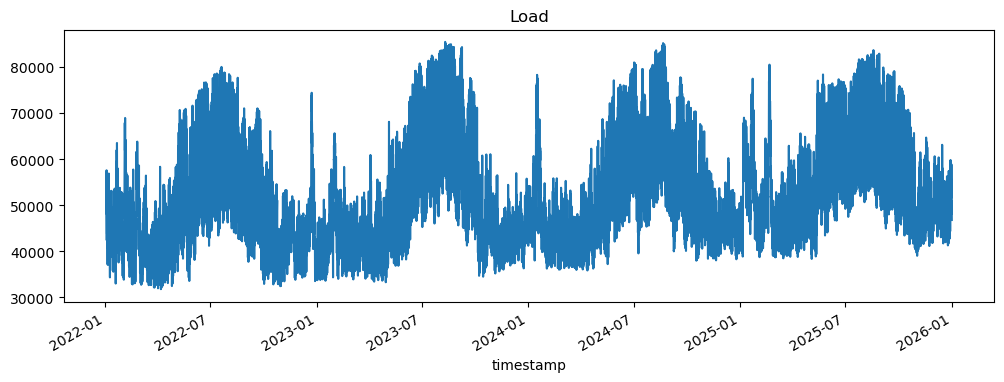

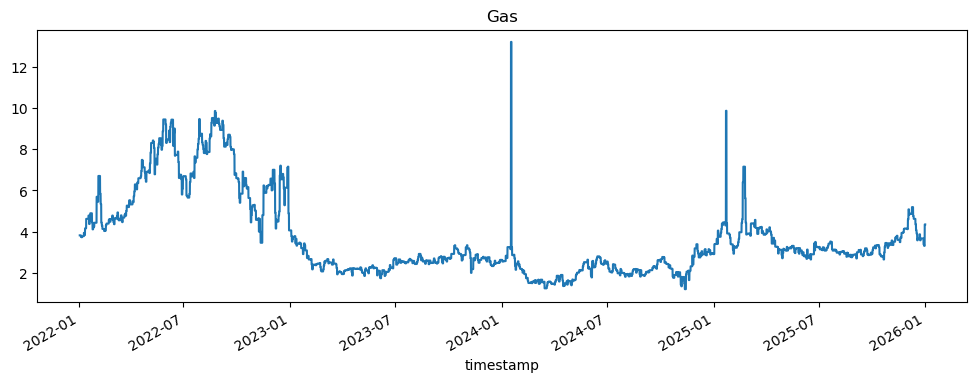

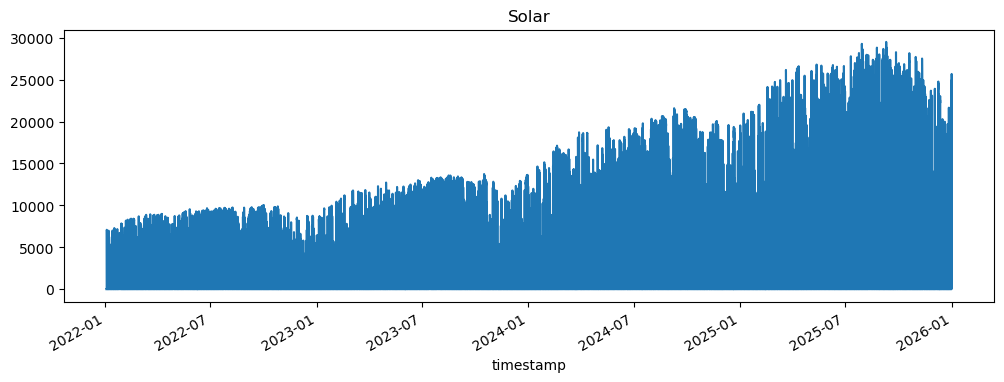

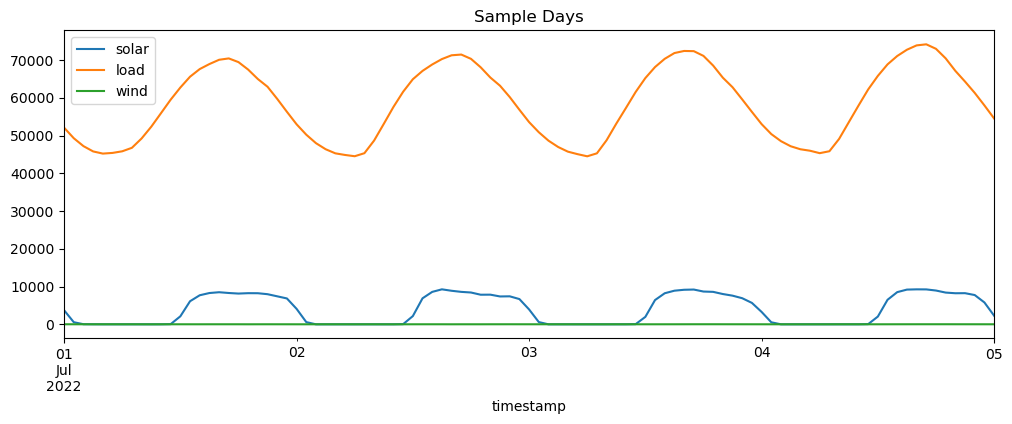

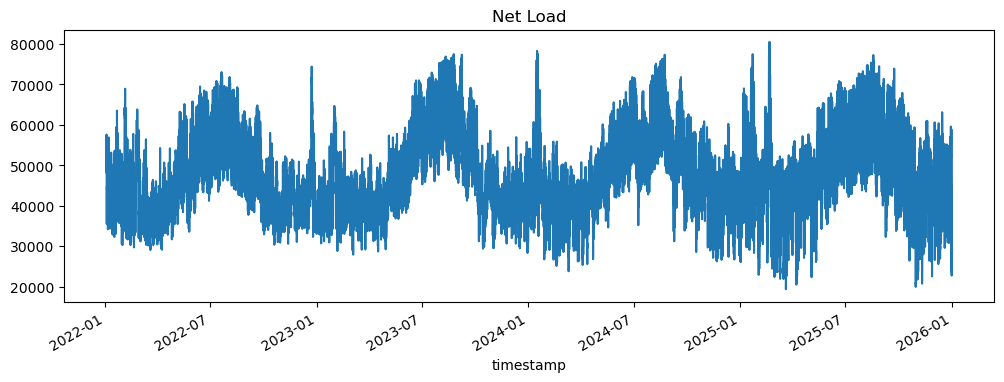

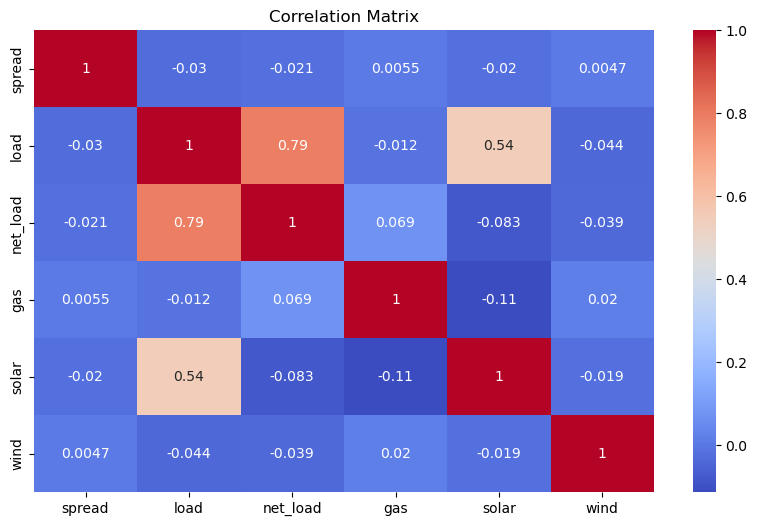

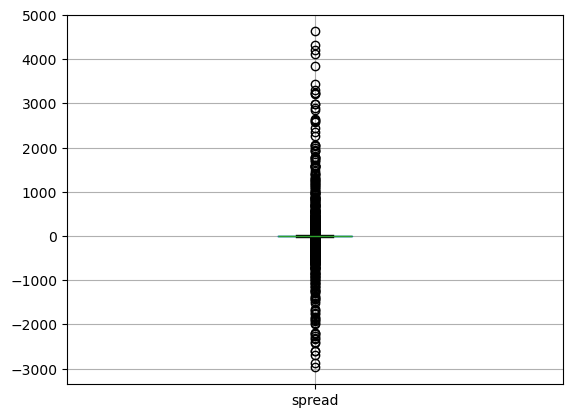

count    35011.000000
mean        -2.835454
std        129.890114
min      -2973.515000
25%         -8.228750
50%         -2.060000
75%          2.492500
max       4627.787500
Name: spread, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load
df = pd.read_csv('ercot_power_dataset_clean.csv')

# make sure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# basic checks
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.head())
print(df.tail())

# duplicate timestamps
print("Duplicate timestamps:", df['timestamp'].duplicated().sum())

# sort
df = df.sort_values('timestamp').reset_index(drop=True)

# hourly continuity
time_diff = df['timestamp'].diff().value_counts()
print(time_diff.head())

# -----------------------------
# HISTOGRAMS
# -----------------------------
cols = ['RT_price', 'DA_price', 'spread', 'temp', 'wind', 'cloud', 'load', 'gas', 'solar']

df[cols].hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

# -----------------------------
# PRICES
# -----------------------------
df.set_index('timestamp')[['RT_price', 'DA_price']].plot(figsize=(12,4), title='Prices')
plt.savefig('prices.png')
plt.show()

# -----------------------------
# SPREAD
# -----------------------------
df.set_index('timestamp')['spread'].plot(figsize=(12,4), title='Spread')
plt.axhline(0, color='black')
plt.savefig('spread.png')
plt.show()

# -----------------------------
# LOAD
# -----------------------------
df.set_index('timestamp')['load'].plot(figsize=(12,4), title='Load')
plt.savefig('load.png')
plt.show()

# -----------------------------
# GAS
# -----------------------------
df.set_index('timestamp')['gas'].plot(figsize=(12,4), title='Gas')
plt.savefig('gas.png')
plt.show()

# -----------------------------
# SOLAR
# -----------------------------
df.set_index('timestamp')['solar'].plot(figsize=(12,4), title='Solar')
plt.savefig('solar.png')
plt.show()

# -----------------------------
# SAMPLE DAYS
# -----------------------------
df_sample = df[(df['timestamp'] >= '2022-07-01') & (df['timestamp'] <= '2022-07-05')]

df_sample.set_index('timestamp')[['solar', 'load', 'wind']].plot(figsize=(12,4), title='Sample Days')
plt.savefig('sample_days.png')
plt.show()

# -----------------------------
# NET LOAD
# -----------------------------
df['renewables'] = df['solar'] + df['wind']
df['net_load'] = df['load'] - df['renewables']

df.set_index('timestamp')['net_load'].plot(figsize=(12,4), title='Net Load')
plt.savefig('net_load.png')
plt.show()

# -----------------------------
# CORRELATION MATRIX
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df[['spread','load','net_load','gas','solar','wind']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

# -----------------------------
# BOXPLOT
# -----------------------------
df[['spread']].boxplot()
plt.savefig('spread_boxplot.png')
plt.show()

# -----------------------------
# SUMMARY
# -----------------------------
print(df['spread'].describe())

In [4]:
import pandas as pd
import numpy as np

df = df.sort_values('timestamp').reset_index(drop=True)

# -----------------------------
# 1. TIME FEATURES
# -----------------------------
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# -----------------------------
# 2. CORE PHYSICAL FEATURES
# -----------------------------
df['renewables'] = df['solar'] + df['wind']
df['net_load'] = df['load'] - df['renewables']

# -----------------------------
# 3. LAG FEATURES
# -----------------------------
df['spread_lag1'] = df['spread'].shift(1)
df['spread_lag24'] = df['spread'].shift(24)

df['net_load_lag24'] = df['net_load'].shift(24)

# -----------------------------
# 4. GAS REGIME FEATURES
# -----------------------------
# gas is daily but repeated hourly, so use 24h changes
df['gas_return_1d'] = df['gas'].pct_change(24)

# 7-day rolling mean on hourly data
df['gas_ma_7d'] = df['gas'].rolling(24 * 7).mean()
df['gas_dev_7d'] = df['gas'] - df['gas_ma_7d']

# -----------------------------
# 5. SPREAD VOLATILITY FEATURE
# -----------------------------
df['spread_vol_24'] = df['spread'].rolling(24).std()

# -----------------------------
# 6. OPTIONAL TARGET
# choose ONE depending on what you want to predict
# -----------------------------
# next-hour spread
df['target_1h'] = df['spread'].shift(-1)

# next-day spread
df['target_24h'] = df['spread'].shift(-24)

# -----------------------------
# 7. DROP NA ROWS CREATED BY LAGS/ROLLS
# -----------------------------
df_model = df.dropna().reset_index(drop=True)

# -----------------------------
# 8. TIER 1 FEATURE LIST
# -----------------------------
tier1_features = [
    'hour',
    'dayofweek',
    'month',
    'spread_lag1',
    'spread_lag24',
    'load',
    'solar',
    'wind',
    'gas',
    'renewables',
    'net_load',
    'gas_return_1d',
    'gas_dev_7d',
    'net_load_lag24',
    'spread_vol_24'
]

# -----------------------------
# 9. QUICK CHECK
# -----------------------------
print("Final modeling dataframe shape:", df_model.shape)
print("\nTier 1 features:")
print(tier1_features)

print("\nMissing values in Tier 1 features:")
print(df_model[tier1_features].isna().sum())

print("\nPreview:")
print(df_model[['timestamp'] + tier1_features + ['target_1h', 'target_24h']].head())

Final modeling dataframe shape: (34820, 24)

Tier 1 features:
['hour', 'dayofweek', 'month', 'spread_lag1', 'spread_lag24', 'load', 'solar', 'wind', 'gas', 'renewables', 'net_load', 'gas_return_1d', 'gas_dev_7d', 'net_load_lag24', 'spread_vol_24']

Missing values in Tier 1 features:
hour              0
dayofweek         0
month             0
spread_lag1       0
spread_lag24      0
load              0
solar             0
wind              0
gas               0
renewables        0
net_load          0
gas_return_1d     0
gas_dev_7d        0
net_load_lag24    0
spread_vol_24     0
dtype: int64

Preview:
            timestamp  hour  dayofweek  month  spread_lag1  spread_lag24  \
0 2022-01-09 23:00:00    23          6      1      -6.8925       -3.6950   
1 2022-01-10 00:00:00     0          0      1      -4.9350       -4.6550   
2 2022-01-10 01:00:00     1          0      1      -7.2100       -1.3225   
3 2022-01-10 02:00:00     2          0      1      -3.9900      -14.9200   
4 2022-01-10 

In [5]:
# sort (just in case)
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

# 80/20 split by time
split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[tier1_features]
X_test  = test[tier1_features]

# try both targets later; start with 24h
y_train = train['target_24h']
y_test  = test['target_24h']

print(X_train.shape, X_test.shape)

(27856, 15) (6964, 15)


In [6]:
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse)

corr = np.corrcoef(y_test, pred_test)[0, 1]
print("Test Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3097
[LightGBM] [Info] Number of data points in the train set: 27856, number of used features: 15
[LightGBM] [Info] Start training from score -3.194572
Test RMSE: 42.3398959692112
Test Corr: -0.04795200892993196


In [7]:
y_train = train['target_1h']
y_test = test['target_1h']

from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse)

corr = np.corrcoef(y_test, pred_test)[0, 1]
print("Test Corr:", corr)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3097
[LightGBM] [Info] Number of data points in the train set: 27856, number of used features: 15
[LightGBM] [Info] Start training from score -3.188884
Test RMSE: 50.028863037444594
Test Corr: 0.035756563404791206


In [8]:
df_model['target_abs_1h'] = df_model['target_1h'].abs()

# re-split to be safe
train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[tier1_features]
X_test  = test[tier1_features]

y_train = train['target_abs_1h']
y_test  = test['target_abs_1h']

from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse)

corr = np.corrcoef(y_test, pred_test)[0, 1]
print("Test Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3097
[LightGBM] [Info] Number of data points in the train set: 27856, number of used features: 15
[LightGBM] [Info] Start training from score 26.045902
Test RMSE: 40.78317821547509
Test Corr: 0.2738307934346186


In [9]:
import numpy as np
import pandas as pd

# make sure sorted
df = df.sort_values('timestamp').reset_index(drop=True)

# -----------------------------
# TIER 2 FEATURES
# -----------------------------

# lagged physicals
df['load_lag24'] = df['load'].shift(24)
df['temp_lag24'] = df['temp'].shift(24)
df['solar_lag24'] = df['solar'].shift(24)
df['wind_lag24'] = df['wind'].shift(24)

# first-difference in net load
df['net_load_diff1'] = df['net_load'].diff(1)

# deviation of net load from 24h rolling average
df['net_load_ma_24'] = df['net_load'].rolling(24).mean()
df['net_load_dev_24'] = df['net_load'] - df['net_load_ma_24']

# rolling spread mean
df['spread_mean_24'] = df['spread'].rolling(24).mean()

# cyclical encoding of hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# -----------------------------
# UPDATED FEATURE LISTS
# -----------------------------
tier2_features = [
    'load_lag24',
    'temp',
    'temp_lag24',
    'solar_lag24',
    'wind_lag24',
    'net_load_diff1',
    'net_load_dev_24',
    'spread_mean_24',
    'hour_sin',
    'hour_cos'
]

all_features = tier1_features + tier2_features

# -----------------------------
# REBUILD MODELING DATAFRAME
# -----------------------------
df_model = df.dropna().reset_index(drop=True)

print("Updated df_model shape:", df_model.shape)
print("\nMissing values in new features:")
print(df_model[tier2_features].isna().sum())

print("\nPreview:")
print(df_model[['timestamp'] + tier2_features].head())

Updated df_model shape: (34820, 34)

Missing values in new features:
load_lag24         0
temp               0
temp_lag24         0
solar_lag24        0
wind_lag24         0
net_load_diff1     0
net_load_dev_24    0
spread_mean_24     0
hour_sin           0
hour_cos           0
dtype: int64

Preview:
            timestamp    load_lag24  temp  temp_lag24  solar_lag24  \
0 2022-01-09 23:00:00  37368.764271  12.5        18.5       1185.0   
1 2022-01-10 00:00:00  35966.457439  12.6        18.9        197.0   
2 2022-01-10 01:00:00  35002.691497  13.4        19.1         56.0   
3 2022-01-10 02:00:00  34507.196746  13.3        18.9          0.0   
4 2022-01-10 03:00:00  34353.826549  13.4        19.0          0.0   

   wind_lag24  net_load_diff1  net_load_dev_24  spread_mean_24  hour_sin  \
0        19.7      133.419017      1029.032152       -8.678646 -0.258819   
1        17.5     -714.576839       161.897736       -8.785104  0.000000   
2        31.4     -291.224861      -304.611413   

In [10]:
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[all_features]
X_test  = test[all_features]

y_train = train['target_1h']
y_test  = test['target_1h']

from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse)

corr = np.corrcoef(y_test, pred_test)[0, 1]
print("Test Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5176
[LightGBM] [Info] Number of data points in the train set: 27856, number of used features: 25
[LightGBM] [Info] Start training from score -3.188884
Test RMSE: 45.922085418894135
Test Corr: 0.12824160578905142


In [11]:
# create absolute-value targets
df_model['target_abs_1h'] = df_model['target_1h'].abs()
df_model['target_abs_24h'] = df_model['target_24h'].abs()

# sort and split
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[all_features]
X_test  = test[all_features]

y_train = train['target_abs_1h']
y_test  = test['target_abs_1h']

from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse)

corr = np.corrcoef(y_test, pred_test)[0, 1]
print("Test Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5176
[LightGBM] [Info] Number of data points in the train set: 27856, number of used features: 25
[LightGBM] [Info] Start training from score 26.045902
Test RMSE: 41.451252901834515
Test Corr: 0.25305948192927985


In [12]:
df_model = df_model.sort_values('timestamp')

train = df_model[df_model['timestamp'] < '2025-01-01']
test  = df_model[df_model['timestamp'] >= '2025-01-01']

X_train = train[all_features]
X_test  = test[all_features]

y_train = train['target_abs_1h']
y_test  = test['target_abs_1h']

model_vol = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model_vol.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

pred_vol = model_vol.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_vol))
print("Vol RMSE:", rmse)

corr = np.corrcoef(y_test, pred_vol)[0, 1]
print("Vol Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5173
[LightGBM] [Info] Number of data points in the train set: 26085, number of used features: 25
[LightGBM] [Info] Start training from score 27.059538
Vol RMSE: 41.067334404729586
Vol Corr: 0.31555104908049364


In [13]:
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# SORT + TIME SPLIT
# -----------------------------
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

train = df_model[df_model['timestamp'] < '2025-01-01']
test  = df_model[df_model['timestamp'] >= '2025-01-01']

# -----------------------------
# FEATURES + TARGET
# -----------------------------
X_train = train[all_features]
X_test  = test[all_features]

y_train = train['target_1h']
y_test  = test['target_1h']

# -----------------------------
# DIRECTIONAL MODEL
# -----------------------------
model_dir = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model_dir.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2'
)

# -----------------------------
# PREDICTIONS + METRICS
# -----------------------------
pred_dir = model_dir.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_dir))
print("Dir RMSE:", rmse)

corr = np.corrcoef(y_test, pred_dir)[0, 1]
print("Dir Corr:", corr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5173
[LightGBM] [Info] Number of data points in the train set: 26085, number of used features: 25
[LightGBM] [Info] Start training from score -3.338504
Dir RMSE: 45.15180279178342
Dir Corr: 0.15517638067331307


In [14]:
print("Train rows:", len(train))
print("Test rows:", len(test))
print("Predictions:", len(pred_dir))

Train rows: 26085
Test rows: 8735
Predictions: 8735


Baseline Fixed Sign: {'mean_pnl': np.float64(1.3485692615912992), 'std_pnl': np.float64(26.877902182088874), 'sharpe': np.float64(0.05017390317351368), 'trades': 701, 'max_drawdown': np.float64(-1200.2125)}
Drawdown Stop: {'mean_pnl': np.float64(1.4124035489410416), 'std_pnl': np.float64(24.908187376124957), 'sharpe': np.float64(0.05670438910760971), 'trades': 629, 'max_drawdown': np.float64(-483.5174999999999)}
Rolling Loss Filter: {'mean_pnl': np.float64(1.4576888952489981), 'std_pnl': np.float64(26.438572008608922), 'sharpe': np.float64(0.05513493295985675), 'trades': 672, 'max_drawdown': np.float64(-1200.2125)}
Combined Risk Mgmt: {'mean_pnl': np.float64(1.4867572982255295), 'std_pnl': np.float64(24.61011513631356), 'sharpe': np.float64(0.06041244788943464), 'trades': 616, 'max_drawdown': np.float64(-319.8649999999998)}

Results Table:
                     mean_pnl    std_pnl    sharpe  trades  max_drawdown
Baseline             1.348569  26.877902  0.050174   701.0    -1200.2125
Dr

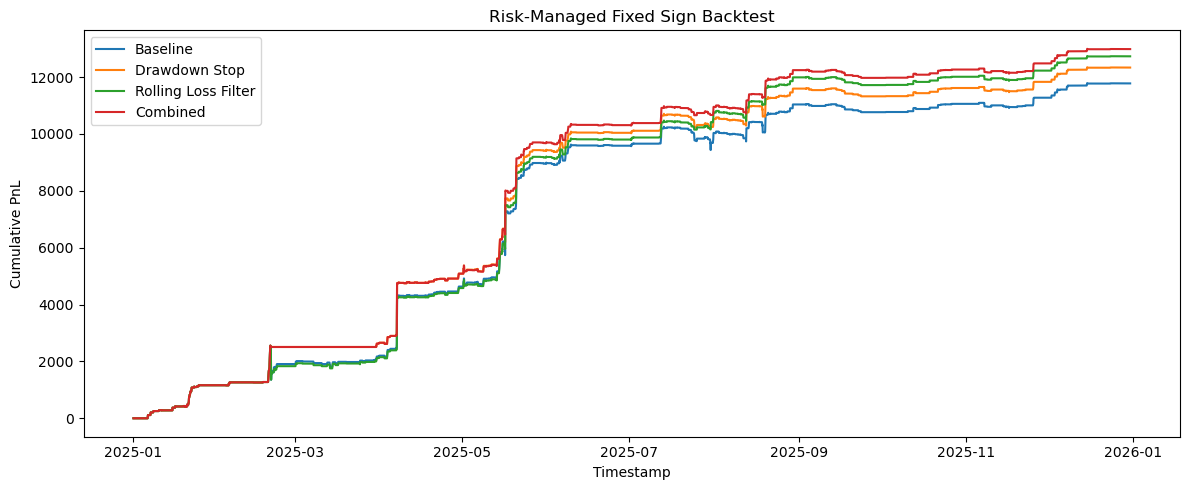

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# RISK-MANAGED FIXED SIGN BACKTEST
# Assumes you already have:
#   - test
#   - pred_dir
#   - pred_vol
# =========================================================

# -----------------------------
# 1. BUILD BACKTEST DATAFRAME
# -----------------------------
test_bt = test.copy().reset_index(drop=True)

test_bt['pred_dir'] = pred_dir
test_bt['pred_vol'] = pred_vol

test_bt = test_bt.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# -----------------------------
# 2. TRADE FILTERS
# -----------------------------
vol_q = 0.90
dir_q = 0.70

vol_threshold = test_bt['pred_vol'].quantile(vol_q)
dir_threshold = test_bt['pred_dir'].abs().quantile(dir_q)

test_bt['trade_flag'] = (
    (test_bt['pred_vol'] > vol_threshold) &
    (test_bt['pred_dir'].abs() > dir_threshold)
).astype(int)

# -----------------------------
# 3. BASELINE FIXED SIGN
# -----------------------------
test_bt['pos_base'] = np.sign(test_bt['pred_dir']) * test_bt['trade_flag']
test_bt['pnl_base'] = test_bt['pos_base'] * test_bt['target_1h']
test_bt['cum_pnl_base'] = test_bt['pnl_base'].cumsum()

# -----------------------------
# 4. DRAWDOWN STOP
# -----------------------------
max_dd_allowed = -500  # tune later

test_bt['running_max_base'] = test_bt['cum_pnl_base'].cummax()
test_bt['drawdown_base'] = test_bt['cum_pnl_base'] - test_bt['running_max_base']

# risk off after breaching drawdown threshold
test_bt['risk_off_dd'] = (test_bt['drawdown_base'] < max_dd_allowed).astype(int)

test_bt['pos_dd'] = test_bt['pos_base'] * (1 - test_bt['risk_off_dd'])
test_bt['pnl_dd'] = test_bt['pos_dd'] * test_bt['target_1h']
test_bt['cum_pnl_dd'] = test_bt['pnl_dd'].cumsum()

# -----------------------------
# 5. ROLLING LOSS FILTER
# -----------------------------
rolling_window = 24       # last 24 hours
rolling_loss_limit = -150 # tune later

test_bt['rolling_pnl_base'] = test_bt['pnl_base'].rolling(rolling_window, min_periods=1).sum()
test_bt['risk_off_roll'] = (test_bt['rolling_pnl_base'] < rolling_loss_limit).astype(int)

test_bt['pos_roll'] = test_bt['pos_base'] * (1 - test_bt['risk_off_roll'])
test_bt['pnl_roll'] = test_bt['pos_roll'] * test_bt['target_1h']
test_bt['cum_pnl_roll'] = test_bt['pnl_roll'].cumsum()

# -----------------------------
# 6. COMBINED RISK MANAGEMENT
# -----------------------------
test_bt['risk_off_combined'] = (
    (test_bt['risk_off_dd'] == 1) |
    (test_bt['risk_off_roll'] == 1)
).astype(int)

test_bt['pos_combined'] = test_bt['pos_base'] * (1 - test_bt['risk_off_combined'])
test_bt['pnl_combined'] = test_bt['pos_combined'] * test_bt['target_1h']
test_bt['cum_pnl_combined'] = test_bt['pnl_combined'].cumsum()

# -----------------------------
# 7. SUMMARY FUNCTION
# -----------------------------
def summarize_strategy(pnl, pos):
    pnl = pd.Series(pnl).dropna()
    pos = pd.Series(pos).fillna(0)

    mean_pnl = pnl.mean()
    std_pnl = pnl.std()
    sharpe = mean_pnl / std_pnl if std_pnl > 0 else np.nan
    trades = int((pos != 0).sum())

    cum = pnl.cumsum()
    running_max = cum.cummax()
    drawdown = cum - running_max
    max_dd = drawdown.min()

    return {
        'mean_pnl': mean_pnl,
        'std_pnl': std_pnl,
        'sharpe': sharpe,
        'trades': trades,
        'max_drawdown': max_dd
    }

# -----------------------------
# 8. PRINT RESULTS
# -----------------------------
base_stats = summarize_strategy(test_bt['pnl_base'], test_bt['pos_base'])
dd_stats = summarize_strategy(test_bt['pnl_dd'], test_bt['pos_dd'])
roll_stats = summarize_strategy(test_bt['pnl_roll'], test_bt['pos_roll'])
combined_stats = summarize_strategy(test_bt['pnl_combined'], test_bt['pos_combined'])

print("Baseline Fixed Sign:", base_stats)
print("Drawdown Stop:", dd_stats)
print("Rolling Loss Filter:", roll_stats)
print("Combined Risk Mgmt:", combined_stats)

results_table = pd.DataFrame({
    'Baseline': base_stats,
    'Drawdown Stop': dd_stats,
    'Rolling Loss Filter': roll_stats,
    'Combined': combined_stats
}).T

print("\nResults Table:")
print(results_table)

# -----------------------------
# 9. PLOTS
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(test_bt['timestamp'], test_bt['cum_pnl_base'], label='Baseline')
plt.plot(test_bt['timestamp'], test_bt['cum_pnl_dd'], label='Drawdown Stop')
plt.plot(test_bt['timestamp'], test_bt['cum_pnl_roll'], label='Rolling Loss Filter')
plt.plot(test_bt['timestamp'], test_bt['cum_pnl_combined'], label='Combined')
plt.legend()
plt.title('Risk-Managed Fixed Sign Backtest')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative PnL')
plt.tight_layout()
plt.savefig('Risk-Managed Fixed Sign Backtest 2025.png')
plt.show()

In [16]:
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# SORT + TIME SPLIT (2022–2023 train, 2024 test)
# -----------------------------
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

train_2024 = df_model[df_model['timestamp'] < '2024-01-01']
test_2024 = df_model[
    (df_model['timestamp'] >= '2024-01-01') &
    (df_model['timestamp'] < '2025-01-01')
]

print("Train rows:", len(train_2024))
print("Test rows:", len(test_2024))

# -----------------------------
# FEATURES + TARGET
# -----------------------------
X_train_2024 = train_2024[all_features]
X_test_2024  = test_2024[all_features]

y_train_2024 = train_2024['target_1h']
y_test_2024  = test_2024['target_1h']

# -----------------------------
# DIRECTIONAL MODEL (2024 TEST)
# -----------------------------
model_dir_2024 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model_dir_2024.fit(
    X_train_2024,
    y_train_2024,
    eval_set=[(X_test_2024, y_test_2024)],
    eval_metric='l2'
)

# -----------------------------
# PREDICTIONS + METRICS
# -----------------------------
pred_dir_2024 = model_dir_2024.predict(X_test_2024)

rmse_2024 = np.sqrt(mean_squared_error(y_test_2024, pred_dir_2024))
print("2024 Dir RMSE:", rmse_2024)

corr_2024 = np.corrcoef(y_test_2024, pred_dir_2024)[0, 1]
print("2024 Dir Corr:", corr_2024)

Train rows: 17302
Test rows: 8783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5180
[LightGBM] [Info] Number of data points in the train set: 17302, number of used features: 25
[LightGBM] [Info] Start training from score -4.333150
2024 Dir RMSE: 71.07943240821952
2024 Dir Corr: 0.18075868443620724


In [17]:
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# SORT + TIME SPLIT (2022–2023 train, 2024 test)
# -----------------------------
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

train_2024 = df_model[df_model['timestamp'] < '2024-01-01']
test_2024 = df_model[
    (df_model['timestamp'] >= '2024-01-01') &
    (df_model['timestamp'] < '2025-01-01')
]

print("Train rows:", len(train_2024))
print("Test rows:", len(test_2024))

# -----------------------------
# FEATURES + TARGET
# -----------------------------
X_train_2024 = train_2024[all_features]
X_test_2024  = test_2024[all_features]

y_train_2024 = train_2024['target_abs_1h']
y_test_2024  = test_2024['target_abs_1h']

# -----------------------------
# VOLATILITY MODEL (2024 TEST)
# -----------------------------
model_vol_2024 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model_vol_2024.fit(
    X_train_2024,
    y_train_2024,
    eval_set=[(X_test_2024, y_test_2024)],
    eval_metric='l2'
)

# -----------------------------
# PREDICTIONS + METRICS
# -----------------------------
pred_vol_2024 = model_vol_2024.predict(X_test_2024)

rmse_vol_2024 = np.sqrt(mean_squared_error(y_test_2024, pred_vol_2024))
print("2024 Vol RMSE:", rmse_vol_2024)

corr_vol_2024 = np.corrcoef(y_test_2024, pred_vol_2024)[0, 1]
print("2024 Vol Corr:", corr_vol_2024)

Train rows: 17302
Test rows: 8783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5180
[LightGBM] [Info] Number of data points in the train set: 17302, number of used features: 25
[LightGBM] [Info] Start training from score 34.773338
2024 Vol RMSE: 61.70359898116125
2024 Vol Corr: 0.37226285788964314


2024 Baseline Fixed Sign: {'mean_pnl': np.float64(1.6518458954799042), 'std_pnl': np.float64(53.46139831036391), 'hourly_sharpe': np.float64(0.03089791789377273), 'daily_sharpe': np.float64(0.13166943073866388), 'annualized_sharpe': np.float64(2.09018741402369), 'trades': np.int64(775), 'max_drawdown': np.float64(-3411.557499999999)}
2024 Drawdown Stop: {'mean_pnl': np.float64(2.057873448707731), 'std_pnl': np.float64(40.65289125275722), 'hourly_sharpe': np.float64(0.050620592663705284), 'daily_sharpe': np.float64(0.17247323457337302), 'annualized_sharpe': np.float64(2.737927718976314), 'trades': np.int64(421), 'max_drawdown': np.float64(-421.9899999999998)}
2024 Rolling Loss Filter: {'mean_pnl': np.float64(2.348170329044745), 'std_pnl': np.float64(48.993985532959066), 'hourly_sharpe': np.float64(0.04792772630152923), 'daily_sharpe': np.float64(0.17580604951386383), 'annualized_sharpe': np.float64(2.7908345159663495), 'trades': np.int64(691), 'max_drawdown': np.float64(-1256.8475000000

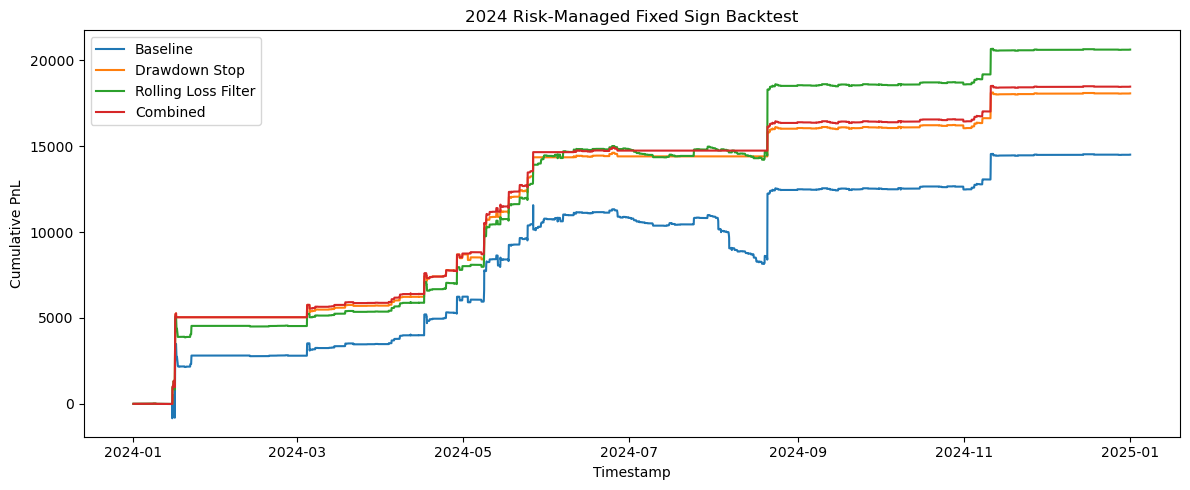

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# RISK-MANAGED FIXED SIGN BACKTEST — 2024
# Assumes you already have:
#   test_2024
#   pred_dir_2024
#   pred_vol_2024
# =========================================================

test_bt_2024 = test_2024.copy().reset_index(drop=True)

test_bt_2024['pred_dir'] = pred_dir_2024
test_bt_2024['pred_vol'] = pred_vol_2024

test_bt_2024 = (
    test_bt_2024
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

# -----------------------------
# TRADE FILTERS
# -----------------------------
vol_q = 0.90
dir_q = 0.70

vol_threshold = test_bt_2024['pred_vol'].quantile(vol_q)
dir_threshold = test_bt_2024['pred_dir'].abs().quantile(dir_q)

test_bt_2024['trade_flag'] = (
    (test_bt_2024['pred_vol'] > vol_threshold) &
    (test_bt_2024['pred_dir'].abs() > dir_threshold)
).astype(int)

# -----------------------------
# BASELINE FIXED SIGN
# -----------------------------
test_bt_2024['pos_base'] = np.sign(test_bt_2024['pred_dir']) * test_bt_2024['trade_flag']
test_bt_2024['pnl_base'] = test_bt_2024['pos_base'] * test_bt_2024['target_1h']
test_bt_2024['cum_pnl_base'] = test_bt_2024['pnl_base'].cumsum()

# -----------------------------
# DRAWDOWN STOP
# -----------------------------
max_dd_allowed = -500

test_bt_2024['running_max_base'] = test_bt_2024['cum_pnl_base'].cummax()
test_bt_2024['drawdown_base'] = (
    test_bt_2024['cum_pnl_base'] - test_bt_2024['running_max_base']
)

test_bt_2024['risk_off_dd'] = (
    test_bt_2024['drawdown_base'] < max_dd_allowed
).astype(int)

test_bt_2024['pos_dd'] = test_bt_2024['pos_base'] * (1 - test_bt_2024['risk_off_dd'])
test_bt_2024['pnl_dd'] = test_bt_2024['pos_dd'] * test_bt_2024['target_1h']
test_bt_2024['cum_pnl_dd'] = test_bt_2024['pnl_dd'].cumsum()

# -----------------------------
# ROLLING LOSS FILTER
# -----------------------------
rolling_window = 24
rolling_loss_limit = -150

test_bt_2024['rolling_pnl_base'] = (
    test_bt_2024['pnl_base']
    .rolling(rolling_window, min_periods=1)
    .sum()
)

test_bt_2024['risk_off_roll'] = (
    test_bt_2024['rolling_pnl_base'] < rolling_loss_limit
).astype(int)

test_bt_2024['pos_roll'] = test_bt_2024['pos_base'] * (1 - test_bt_2024['risk_off_roll'])
test_bt_2024['pnl_roll'] = test_bt_2024['pos_roll'] * test_bt_2024['target_1h']
test_bt_2024['cum_pnl_roll'] = test_bt_2024['pnl_roll'].cumsum()

# -----------------------------
# COMBINED RISK MANAGEMENT
# -----------------------------
test_bt_2024['risk_off_combined'] = (
    (test_bt_2024['risk_off_dd'] == 1) |
    (test_bt_2024['risk_off_roll'] == 1)
).astype(int)

test_bt_2024['pos_combined'] = (
    test_bt_2024['pos_base'] * (1 - test_bt_2024['risk_off_combined'])
)

test_bt_2024['pnl_combined'] = (
    test_bt_2024['pos_combined'] * test_bt_2024['target_1h']
)

test_bt_2024['cum_pnl_combined'] = test_bt_2024['pnl_combined'].cumsum()

# -----------------------------
# SUMMARY FUNCTION
# -----------------------------
def summarize_strategy(pnl, pos, timestamps):
    pnl = pd.Series(pnl).dropna()
    pos = pd.Series(pos).fillna(0)
    timestamps = pd.to_datetime(timestamps)

    mean = pnl.mean()
    std = pnl.std()
    sharpe_hourly = mean / std if std > 0 else np.nan
    trades = (pos != 0).sum()

    cum = pnl.cumsum()
    dd = cum - cum.cummax()

    # daily aggregated PnL Sharpe
    daily_pnl = pd.DataFrame({
        'timestamp': timestamps,
        'pnl': pnl
    }).dropna()

    daily_pnl['date'] = daily_pnl['timestamp'].dt.date
    daily_pnl = daily_pnl.groupby('date')['pnl'].sum()

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    sharpe_daily = daily_mean / daily_std if daily_std > 0 else np.nan
    sharpe_annualized = sharpe_daily * np.sqrt(252)

    return {
        'mean_pnl': mean,
        'std_pnl': std,
        'hourly_sharpe': sharpe_hourly,
        'daily_sharpe': sharpe_daily,
        'annualized_sharpe': sharpe_annualized,
        'trades': trades,
        'max_drawdown': dd.min()
    }
# -----------------------------
# RESULTS
# -----------------------------
base_stats_2024 = summarize_strategy(
    test_bt_2024['pnl_base'],
    test_bt_2024['pos_base'],
    test_bt_2024['timestamp']
)

dd_stats_2024 = summarize_strategy(
    test_bt_2024['pnl_dd'],
    test_bt_2024['pos_dd'],
    test_bt_2024['timestamp']
)

roll_stats_2024 = summarize_strategy(
    test_bt_2024['pnl_roll'],
    test_bt_2024['pos_roll'],
    test_bt_2024['timestamp']
)

combined_stats_2024 = summarize_strategy(
    test_bt_2024['pnl_combined'],
    test_bt_2024['pos_combined'],
    test_bt_2024['timestamp']
)
print("2024 Baseline Fixed Sign:", base_stats_2024)
print("2024 Drawdown Stop:", dd_stats_2024)
print("2024 Rolling Loss Filter:", roll_stats_2024)
print("2024 Combined Risk Mgmt:", combined_stats_2024)

results_table_2024 = pd.DataFrame({
    'Baseline': base_stats_2024,
    'Drawdown Stop': dd_stats_2024,
    'Rolling Loss Filter': roll_stats_2024,
    'Combined': combined_stats_2024
}).T

print("\n2024 Results Table:")
print(results_table_2024)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(test_bt_2024['timestamp'], test_bt_2024['cum_pnl_base'], label='Baseline')
plt.plot(test_bt_2024['timestamp'], test_bt_2024['cum_pnl_dd'], label='Drawdown Stop')
plt.plot(test_bt_2024['timestamp'], test_bt_2024['cum_pnl_roll'], label='Rolling Loss Filter')
plt.plot(test_bt_2024['timestamp'], test_bt_2024['cum_pnl_combined'], label='Combined')
plt.legend()
plt.title('2024 Risk-Managed Fixed Sign Backtest')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative PnL')
plt.tight_layout()
plt.savefig('2024 Risk Managed Fixed Sign Backtest')
plt.show()

2025 Net Results: {'mean_pnl': np.float64(1.4162364052661707), 'std_pnl': np.float64(24.55522726607279), 'hourly_sharpe': np.float64(0.057675556814045105), 'daily_sharpe': np.float64(0.20447518291656258), 'annualized_sharpe': np.float64(3.2459428996900046), 'trades': np.int64(616), 'max_drawdown': np.float64(-361.9474999999984)}


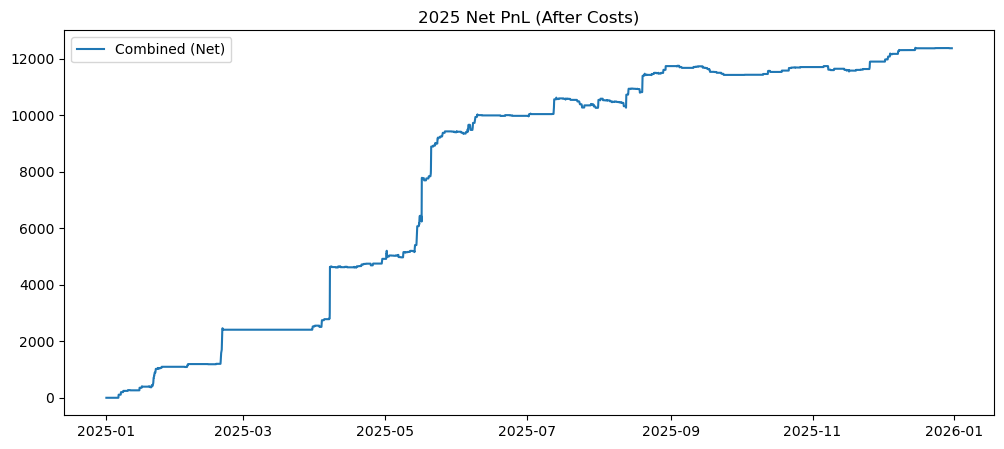

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# BUILD DATA
# -----------------------------
test_bt = test.copy().reset_index(drop=True)

test_bt['pred_dir'] = pred_dir
test_bt['pred_vol'] = pred_vol

test_bt = test_bt.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# -----------------------------
# TRADE FILTER
# -----------------------------
vol_threshold = test_bt['pred_vol'].quantile(0.90)
dir_threshold = test_bt['pred_dir'].abs().quantile(0.70)

test_bt['trade_flag'] = (
    (test_bt['pred_vol'] > vol_threshold) &
    (test_bt['pred_dir'].abs() > dir_threshold)
).astype(int)

# -----------------------------
# BASE SIGNAL
# -----------------------------
test_bt['pos_base'] = np.sign(test_bt['pred_dir']) * test_bt['trade_flag']

# -----------------------------
# RISK MANAGEMENT
# -----------------------------
# Drawdown
test_bt['pnl_base'] = test_bt['pos_base'] * test_bt['target_1h']
test_bt['cum_pnl_base'] = test_bt['pnl_base'].cumsum()

test_bt['running_max'] = test_bt['cum_pnl_base'].cummax()
test_bt['drawdown'] = test_bt['cum_pnl_base'] - test_bt['running_max']

max_dd_allowed = -500
test_bt['risk_off_dd'] = (test_bt['drawdown'] < max_dd_allowed).astype(int)

# Rolling loss
rolling_window = 24
rolling_loss_limit = -150

test_bt['rolling_pnl'] = test_bt['pnl_base'].rolling(rolling_window, min_periods=1).sum()
test_bt['risk_off_roll'] = (test_bt['rolling_pnl'] < rolling_loss_limit).astype(int)

# Combined
test_bt['risk_off'] = (
    (test_bt['risk_off_dd'] == 1) |
    (test_bt['risk_off_roll'] == 1)
).astype(int)

test_bt['pos_combined'] = test_bt['pos_base'] * (1 - test_bt['risk_off'])

# -----------------------------
# TRANSACTION COSTS
# -----------------------------
cost_per_mwh = 1.0

test_bt['pnl_gross'] = test_bt['pos_combined'] * test_bt['target_1h']
test_bt['cost'] = cost_per_mwh * abs(test_bt['pos_combined'])

test_bt['pnl_net'] = test_bt['pnl_gross'] - test_bt['cost']
test_bt['cum_pnl_net'] = test_bt['pnl_net'].cumsum()

# -----------------------------
# SUMMARY
# -----------------------------
def summarize(pnl, pos, timestamps):
    pnl = pd.Series(pnl).dropna()
    pos = pd.Series(pos).fillna(0)
    timestamps = pd.to_datetime(timestamps)

    mean = pnl.mean()
    std = pnl.std()
    sharpe_hourly = mean / std if std > 0 else np.nan
    trades = (pos != 0).sum()

    cum = pnl.cumsum()
    dd = cum - cum.cummax()

    # daily aggregated PnL Sharpe
    daily_pnl = pd.DataFrame({
        'timestamp': timestamps,
        'pnl': pnl
    }).dropna()

    daily_pnl['date'] = daily_pnl['timestamp'].dt.date
    daily_pnl = daily_pnl.groupby('date')['pnl'].sum()

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    sharpe_daily = daily_mean / daily_std if daily_std > 0 else np.nan
    sharpe_annualized = sharpe_daily * np.sqrt(252)

    return {
        'mean_pnl': mean,
        'std_pnl': std,
        'hourly_sharpe': sharpe_hourly,
        'daily_sharpe': sharpe_daily,
        'annualized_sharpe': sharpe_annualized,
        'trades': trades,
        'max_drawdown': dd.min()
    }

print(
    "2025 Net Results:",
    summarize(test_bt['pnl_net'], test_bt['pos_combined'], test_bt['timestamp'])
)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(test_bt['timestamp'], test_bt['cum_pnl_net'], label='Combined (Net)')
plt.legend()
plt.title('2025 Net PnL (After Costs)')
plt.savefig('2025 Net PnL (After Costs).png')
plt.show()

2024 Net Results: {'mean_pnl': np.float64(2.0565043265399066), 'std_pnl': np.float64(40.33905024144028), 'hourly_sharpe': np.float64(0.05098048452383395), 'daily_sharpe': np.float64(0.17363915027714136), 'annualized_sharpe': np.float64(2.7564360569873294), 'trades': np.int64(405), 'max_drawdown': np.float64(-374.58249999999987)}


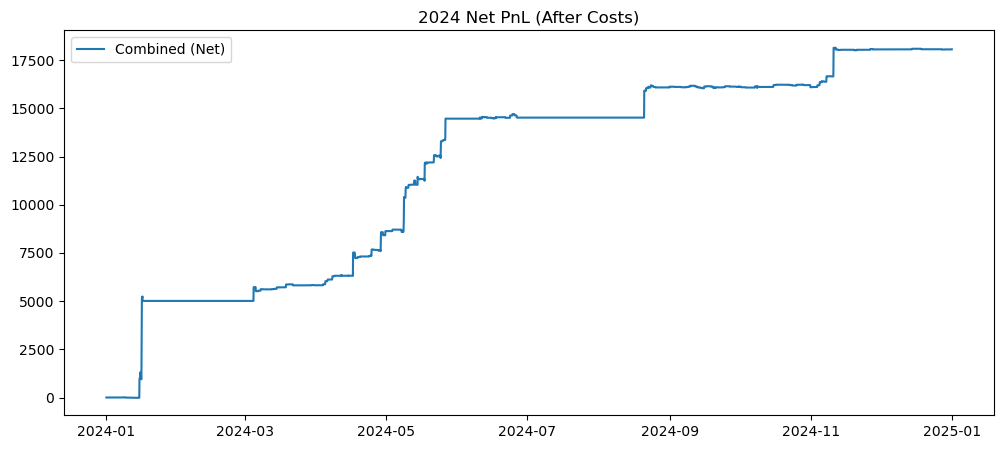

In [20]:
test_bt_2024 = test_2024.copy().reset_index(drop=True)

test_bt_2024['pred_dir'] = pred_dir_2024
test_bt_2024['pred_vol'] = pred_vol_2024

test_bt_2024 = test_bt_2024.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# -----------------------------
# TRADE FILTER
# -----------------------------
vol_threshold = test_bt_2024['pred_vol'].quantile(0.90)
dir_threshold = test_bt_2024['pred_dir'].abs().quantile(0.70)

test_bt_2024['trade_flag'] = (
    (test_bt_2024['pred_vol'] > vol_threshold) &
    (test_bt_2024['pred_dir'].abs() > dir_threshold)
).astype(int)

# -----------------------------
# BASE SIGNAL
# -----------------------------
test_bt_2024['pos_base'] = np.sign(test_bt_2024['pred_dir']) * test_bt_2024['trade_flag']

# -----------------------------
# RISK MANAGEMENT
# -----------------------------
test_bt_2024['pnl_base'] = test_bt_2024['pos_base'] * test_bt_2024['target_1h']
test_bt_2024['cum_pnl_base'] = test_bt_2024['pnl_base'].cumsum()

test_bt_2024['running_max'] = test_bt_2024['cum_pnl_base'].cummax()
test_bt_2024['drawdown'] = test_bt_2024['cum_pnl_base'] - test_bt_2024['running_max']

test_bt_2024['risk_off_dd'] = (test_bt_2024['drawdown'] < -500).astype(int)

test_bt_2024['rolling_pnl'] = test_bt_2024['pnl_base'].rolling(24, min_periods=1).sum()
test_bt_2024['risk_off_roll'] = (test_bt_2024['rolling_pnl'] < -150).astype(int)

test_bt_2024['risk_off'] = (
    (test_bt_2024['risk_off_dd'] == 1) |
    (test_bt_2024['risk_off_roll'] == 1)
).astype(int)

test_bt_2024['pos_combined'] = test_bt_2024['pos_base'] * (1 - test_bt_2024['risk_off'])

# -----------------------------
# TRANSACTION COSTS
# -----------------------------
cost_per_mwh = 1.0

test_bt_2024['pnl_gross'] = test_bt_2024['pos_combined'] * test_bt_2024['target_1h']
test_bt_2024['cost'] = cost_per_mwh * abs(test_bt_2024['pos_combined'])

test_bt_2024['pnl_net'] = test_bt_2024['pnl_gross'] - test_bt_2024['cost']
test_bt_2024['cum_pnl_net'] = test_bt_2024['pnl_net'].cumsum()

print("2024 Net Results:", summarize(test_bt_2024['pnl_net'], test_bt_2024['pos_combined'], test_bt_2024['timestamp']))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(test_bt_2024['timestamp'], test_bt_2024['cum_pnl_net'], label='Combined (Net)')
plt.legend()
plt.title('2024 Net PnL (After Costs)')
plt.savefig('2024 Net PnL (After Costs).png')
plt.show()

Training magnitude threshold: 33.54174568735429
Training directional threshold: 8.994758227169495
Training volatility floor: 4.9759119449649285

Training normalization constants:
Signal median: 62.72433523448644
Volatility median: 0.017831333638880315
Signal/Risk median: 1.3168137487222942

2025 POSITION-SIZING COMPARISON

                 net_pnl_total  mean_hourly_pnl  std_hourly_pnl  \
Fixed 1 MW        11269.392500         1.290142       26.920670   
Signal Only       13322.569877         1.525194       42.593059   
Volatility Only   16263.636566         1.861893       30.514887   
Signal / Risk     15862.156842         1.815931       37.374717   

                 hourly_sharpe  daily_sharpe  annualized_sharpe_365  \
Fixed 1 MW            0.047924      0.181378               3.465230   
Signal Only           0.035809      0.139960               2.673923   
Volatility Only       0.061016      0.198444               3.791271   
Signal / Risk         0.048587      0.177826           

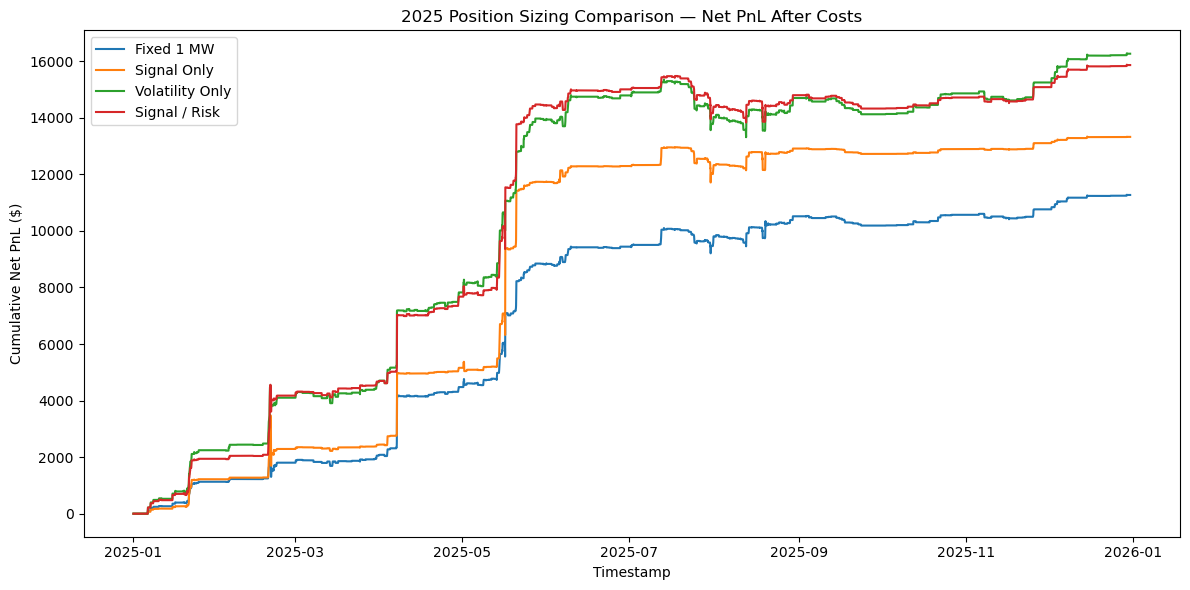

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2025 POSITION-SIZING COMPARISON
#
# Compares:
# 1. Fixed 1 MW
# 2. Signal-strength sizing
# 3. Inverse-volatility sizing
# 4. Signal-to-risk sizing
#
# IMPORTANT:
# - Trade thresholds are estimated from TRAINING data only
# - Sizing normalization is estimated from TRAINING data only
# - No drawdown / rolling-loss filters yet
# - $1/MWh transaction cost included
# ============================================================


# ------------------------------------------------------------
# 1. CREATE TRAIN + TEST PREDICTIONS
# ------------------------------------------------------------

# We already have:
# train, test
# model_dir, model_vol
# X_train, X_test
# pred_dir, pred_vol

# Generate predictions on training set
# These are used ONLY to determine thresholds / scaling constants

pred_dir_train = model_dir.predict(X_train)
pred_vol_train = model_vol.predict(X_train)


# ------------------------------------------------------------
# 2. BUILD TRAINING DATAFRAME
# ------------------------------------------------------------

train_bt = train.copy().reset_index(drop=True)

train_bt['pred_dir'] = pred_dir_train
train_bt['pred_vol'] = pred_vol_train

train_bt = (
    train_bt
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. BUILD 2025 TEST DATAFRAME
# ------------------------------------------------------------

test_size_2025 = test.copy().reset_index(drop=True)

test_size_2025['pred_dir'] = pred_dir
test_size_2025['pred_vol'] = pred_vol

test_size_2025 = (
    test_size_2025
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. TRADE THRESHOLDS — TRAINING DATA ONLY
# ------------------------------------------------------------

vol_q = 0.90
dir_q = 0.70

vol_threshold = train_bt['pred_vol'].quantile(vol_q)
dir_threshold = train_bt['pred_dir'].abs().quantile(dir_q)

print("Training magnitude threshold:", vol_threshold)
print("Training directional threshold:", dir_threshold)


# ------------------------------------------------------------
# 5. APPLY TRADE FILTER TO TRAIN + TEST
# ------------------------------------------------------------

train_bt['trade_flag'] = (
    (train_bt['pred_vol'] > vol_threshold) &
    (train_bt['pred_dir'].abs() > dir_threshold)
).astype(int)

test_size_2025['trade_flag'] = (
    (test_size_2025['pred_vol'] > vol_threshold) &
    (test_size_2025['pred_dir'].abs() > dir_threshold)
).astype(int)


# ------------------------------------------------------------
# 6. VOLATILITY FLOOR
#
# Prevents extremely low trailing volatility from creating
# absurdly large inverse-volatility positions.
#
# Again: calculated from TRAINING data only.
# ------------------------------------------------------------

vol_floor = train_bt['spread_vol_24'].quantile(0.10)

train_bt['risk_vol'] = train_bt['spread_vol_24'].clip(lower=vol_floor)

test_size_2025['risk_vol'] = (
    test_size_2025['spread_vol_24']
    .clip(lower=vol_floor)
)

print("Training volatility floor:", vol_floor)


# ============================================================
# 7. CREATE RAW SIZING SCORES
# ============================================================

# ------------------------------------------------------------
# A. SIGNAL ONLY
#
# Bigger absolute directional prediction = bigger position
# ------------------------------------------------------------

train_bt['score_signal'] = train_bt['pred_dir'].abs()

test_size_2025['score_signal'] = (
    test_size_2025['pred_dir'].abs()
)


# ------------------------------------------------------------
# B. VOLATILITY ONLY
#
# Lower trailing volatility = bigger position
# Higher trailing volatility = smaller position
# ------------------------------------------------------------

train_bt['score_vol'] = 1 / train_bt['risk_vol']

test_size_2025['score_vol'] = (
    1 / test_size_2025['risk_vol']
)


# ------------------------------------------------------------
# C. SIGNAL TO RISK
#
# Stronger predicted edge relative to volatility = bigger size
# ------------------------------------------------------------

train_bt['score_signal_risk'] = (
    train_bt['pred_dir'].abs()
    / train_bt['risk_vol']
)

test_size_2025['score_signal_risk'] = (
    test_size_2025['pred_dir'].abs()
    / test_size_2025['risk_vol']
)


# ============================================================
# 8. NORMALIZE SCORES
#
# Goal:
# Median qualifying training trade = 1 MW
#
# This makes comparison with the original fixed 1 MW strategy
# economically intuitive.
# ============================================================

def get_training_median_score(df, score_col):
    qualifying = df.loc[
        df['trade_flag'] == 1,
        score_col
    ]

    return qualifying.median()


median_signal = get_training_median_score(
    train_bt,
    'score_signal'
)

median_vol = get_training_median_score(
    train_bt,
    'score_vol'
)

median_signal_risk = get_training_median_score(
    train_bt,
    'score_signal_risk'
)

print("\nTraining normalization constants:")
print("Signal median:", median_signal)
print("Volatility median:", median_vol)
print("Signal/Risk median:", median_signal_risk)


# ------------------------------------------------------------
# 9. CONVERT SCORES INTO POSITION SIZES
# ------------------------------------------------------------

min_size = 0.25
max_size = 2.00

test_size_2025['size_signal'] = (
    test_size_2025['score_signal']
    / median_signal
).clip(
    lower=min_size,
    upper=max_size
)

test_size_2025['size_vol'] = (
    test_size_2025['score_vol']
    / median_vol
).clip(
    lower=min_size,
    upper=max_size
)

test_size_2025['size_signal_risk'] = (
    test_size_2025['score_signal_risk']
    / median_signal_risk
).clip(
    lower=min_size,
    upper=max_size
)


# ============================================================
# 10. CREATE POSITIONS
# ============================================================

direction = np.sign(test_size_2025['pred_dir'])
trade_flag = test_size_2025['trade_flag']


# Fixed 1 MW

test_size_2025['pos_fixed'] = (
    direction
    * trade_flag
)


# Signal strength

test_size_2025['pos_signal'] = (
    direction
    * test_size_2025['size_signal']
    * trade_flag
)


# Inverse volatility

test_size_2025['pos_vol'] = (
    direction
    * test_size_2025['size_vol']
    * trade_flag
)


# Signal-to-risk

test_size_2025['pos_signal_risk'] = (
    direction
    * test_size_2025['size_signal_risk']
    * trade_flag
)


# ============================================================
# 11. CALCULATE NET PNL
# ============================================================

cost_per_mwh = 1.0

strategies = {
    'Fixed 1 MW': 'pos_fixed',
    'Signal Only': 'pos_signal',
    'Volatility Only': 'pos_vol',
    'Signal / Risk': 'pos_signal_risk'
}


for strategy_name, pos_col in strategies.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    # Gross PnL
    test_size_2025[f'pnl_gross_{short_name}'] = (
        test_size_2025[pos_col]
        * test_size_2025['target_1h']
    )

    # Transaction cost scales with MW
    test_size_2025[f'cost_{short_name}'] = (
        cost_per_mwh
        * test_size_2025[pos_col].abs()
    )

    # Net PnL
    test_size_2025[f'pnl_net_{short_name}'] = (
        test_size_2025[f'pnl_gross_{short_name}']
        - test_size_2025[f'cost_{short_name}']
    )

    # Cumulative net PnL
    test_size_2025[f'cum_pnl_{short_name}'] = (
        test_size_2025[f'pnl_net_{short_name}']
        .cumsum()
    )


# ============================================================
# 12. SUMMARY FUNCTION
# ============================================================

def summarize_sizing_strategy(
    pnl,
    pos,
    timestamps
):

    results = pd.DataFrame({
        'timestamp': pd.to_datetime(timestamps),
        'pnl': pnl,
        'pos': pos
    }).dropna()

    mean_pnl = results['pnl'].mean()
    std_pnl = results['pnl'].std()

    hourly_sharpe = (
        mean_pnl / std_pnl
        if std_pnl > 0
        else np.nan
    )

    # Cumulative PnL / drawdown
    cumulative = results['pnl'].cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    max_drawdown = drawdown.min()

    # Daily aggregated PnL
    results['date'] = results['timestamp'].dt.date

    daily_pnl = (
        results
        .groupby('date')['pnl']
        .sum()
    )

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    daily_sharpe = (
        daily_mean / daily_std
        if daily_std > 0
        else np.nan
    )

    # Power trades every calendar day
    annualized_sharpe_365 = (
        daily_sharpe * np.sqrt(365)
    )

    # Keep this too so you can compare directly
    # against the original paper's sqrt(252) convention
    annualized_sharpe_252 = (
        daily_sharpe * np.sqrt(252)
    )

    traded_positions = results.loc[
        results['pos'] != 0,
        'pos'
    ]

    return {
        'net_pnl_total': results['pnl'].sum(),
        'mean_hourly_pnl': mean_pnl,
        'std_hourly_pnl': std_pnl,
        'hourly_sharpe': hourly_sharpe,
        'daily_sharpe': daily_sharpe,
        'annualized_sharpe_365': annualized_sharpe_365,
        'annualized_sharpe_252': annualized_sharpe_252,
        'trades': int((results['pos'] != 0).sum()),
        'avg_abs_mw': traded_positions.abs().mean(),
        'max_abs_mw': traded_positions.abs().max(),
        'max_drawdown': max_drawdown
    }


# ============================================================
# 13. SUMMARIZE ALL FOUR STRATEGIES
# ============================================================

results_2025 = {}

for strategy_name, pos_col in strategies.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    pnl_col = f'pnl_net_{short_name}'

    results_2025[strategy_name] = summarize_sizing_strategy(
        test_size_2025[pnl_col],
        test_size_2025[pos_col],
        test_size_2025['timestamp']
    )


results_table_2025 = pd.DataFrame(results_2025).T

print("\n==============================================")
print("2025 POSITION-SIZING COMPARISON")
print("==============================================\n")

print(results_table_2025)


# ============================================================
# 14. PLOT CUMULATIVE NET PNL
# ============================================================

plt.figure(figsize=(12, 6))

for strategy_name in strategies.keys():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    plt.plot(
        test_size_2025['timestamp'],
        test_size_2025[f'cum_pnl_{short_name}'],
        label=strategy_name
    )

plt.title(
    '2025 Position Sizing Comparison — Net PnL After Costs'
)

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net PnL ($)')
plt.legend()
plt.tight_layout()

plt.savefig(
    '2025 Position Sizing Comparison.png',
    dpi=300
)

plt.show()

Training magnitude threshold: 40.44268255468353
Training directional threshold: 10.979012828546331
Training volatility floor: 5.856542252964329

Training normalization constants:
Signal median: 87.395446015366
Volatility median: 0.013835653213437814
Signal/Risk median: 1.4355678764905144

2024 POSITION-SIZING COMPARISON

                 net_pnl_total  mean_hourly_pnl  std_hourly_pnl  \
Fixed 1 MW        12897.330000         1.468442       53.965865   
Signal Only       19945.194040         2.270886       79.938210   
Volatility Only   14418.784495         1.641670       56.051653   
Signal / Risk     20459.154914         2.329404       70.568790   

                 hourly_sharpe  daily_sharpe  annualized_sharpe_365  \
Fixed 1 MW            0.027211      0.117404               2.243003   
Signal Only           0.028408      0.114980               2.196684   
Volatility Only       0.029289      0.119996               2.292519   
Signal / Risk         0.033009      0.129861             

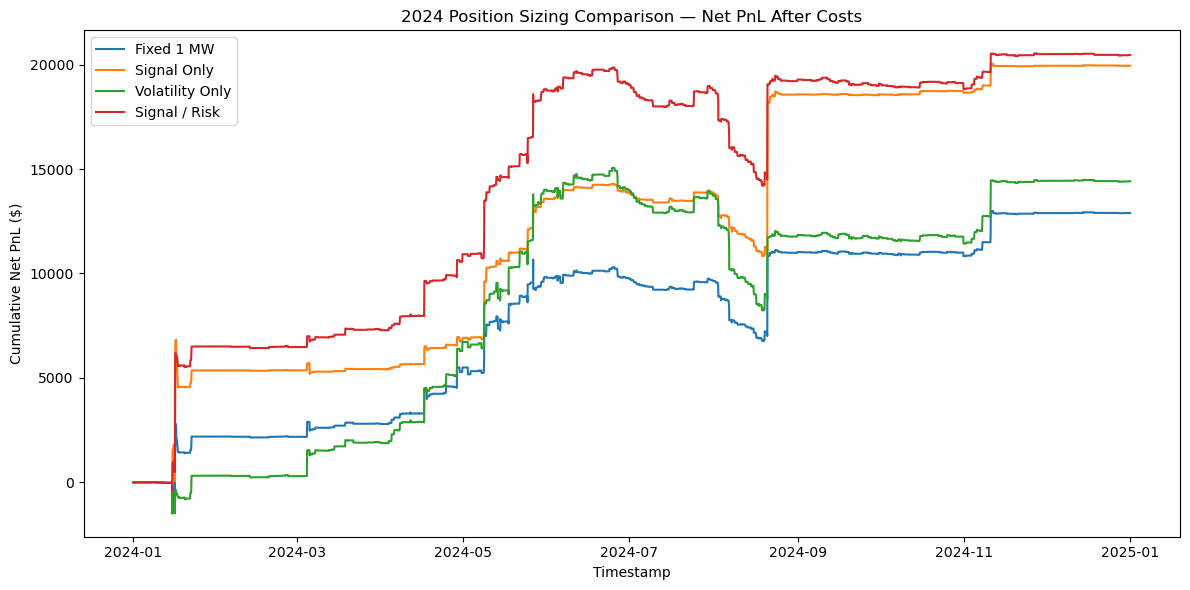

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2024 POSITION-SIZING COMPARISON
#
# 1. Fixed 1 MW
# 2. Signal-strength sizing
# 3. Inverse-volatility sizing
# 4. Signal-to-risk sizing
#
# All thresholds / scaling parameters estimated PRE-2024.
# ============================================================


# ------------------------------------------------------------
# 1. TRAINING PREDICTIONS
# ------------------------------------------------------------

pred_dir_train_2024 = model_dir_2024.predict(X_train_2024)
pred_vol_train_2024 = model_vol_2024.predict(X_train_2024)


# ------------------------------------------------------------
# 2. BUILD TRAINING DATAFRAME
# ------------------------------------------------------------

train_size_2024 = train_2024.copy().reset_index(drop=True)

train_size_2024['pred_dir'] = pred_dir_train_2024
train_size_2024['pred_vol'] = pred_vol_train_2024

train_size_2024 = (
    train_size_2024
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. BUILD 2024 TEST DATAFRAME
# ------------------------------------------------------------

test_size_2024 = test_2024.copy().reset_index(drop=True)

test_size_2024['pred_dir'] = pred_dir_2024
test_size_2024['pred_vol'] = pred_vol_2024

test_size_2024 = (
    test_size_2024
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. TRADE THRESHOLDS — PRE-2024 DATA ONLY
# ------------------------------------------------------------

vol_q = 0.90
dir_q = 0.70

vol_threshold_2024 = train_size_2024['pred_vol'].quantile(vol_q)
dir_threshold_2024 = train_size_2024['pred_dir'].abs().quantile(dir_q)

print("Training magnitude threshold:", vol_threshold_2024)
print("Training directional threshold:", dir_threshold_2024)


# ------------------------------------------------------------
# 5. APPLY SAME FILTER TO TRAIN + 2024
# ------------------------------------------------------------

train_size_2024['trade_flag'] = (
    (train_size_2024['pred_vol'] > vol_threshold_2024) &
    (train_size_2024['pred_dir'].abs() > dir_threshold_2024)
).astype(int)

test_size_2024['trade_flag'] = (
    (test_size_2024['pred_vol'] > vol_threshold_2024) &
    (test_size_2024['pred_dir'].abs() > dir_threshold_2024)
).astype(int)


# ------------------------------------------------------------
# 6. VOLATILITY FLOOR — PRE-2024 ONLY
# ------------------------------------------------------------

vol_floor_2024 = (
    train_size_2024['spread_vol_24']
    .quantile(0.10)
)

train_size_2024['risk_vol'] = (
    train_size_2024['spread_vol_24']
    .clip(lower=vol_floor_2024)
)

test_size_2024['risk_vol'] = (
    test_size_2024['spread_vol_24']
    .clip(lower=vol_floor_2024)
)

print("Training volatility floor:", vol_floor_2024)


# ============================================================
# 7. RAW SIZING SCORES
# ============================================================

# A. SIGNAL STRENGTH
train_size_2024['score_signal'] = (
    train_size_2024['pred_dir'].abs()
)

test_size_2024['score_signal'] = (
    test_size_2024['pred_dir'].abs()
)


# B. INVERSE VOLATILITY
train_size_2024['score_vol'] = (
    1 / train_size_2024['risk_vol']
)

test_size_2024['score_vol'] = (
    1 / test_size_2024['risk_vol']
)


# C. SIGNAL / RISK
train_size_2024['score_signal_risk'] = (
    train_size_2024['pred_dir'].abs()
    / train_size_2024['risk_vol']
)

test_size_2024['score_signal_risk'] = (
    test_size_2024['pred_dir'].abs()
    / test_size_2024['risk_vol']
)


# ============================================================
# 8. TRAINING NORMALIZATION CONSTANTS
# ============================================================

def training_median_2024(df, score_col):

    qualifying = df.loc[
        df['trade_flag'] == 1,
        score_col
    ]

    return qualifying.median()


median_signal_2024 = training_median_2024(
    train_size_2024,
    'score_signal'
)

median_vol_2024 = training_median_2024(
    train_size_2024,
    'score_vol'
)

median_signal_risk_2024 = training_median_2024(
    train_size_2024,
    'score_signal_risk'
)

print("\nTraining normalization constants:")
print("Signal median:", median_signal_2024)
print("Volatility median:", median_vol_2024)
print("Signal/Risk median:", median_signal_risk_2024)


# ============================================================
# 9. POSITION SIZES
# ============================================================

min_size = 0.25
max_size = 2.00

test_size_2024['size_signal'] = (
    test_size_2024['score_signal']
    / median_signal_2024
).clip(
    lower=min_size,
    upper=max_size
)

test_size_2024['size_vol'] = (
    test_size_2024['score_vol']
    / median_vol_2024
).clip(
    lower=min_size,
    upper=max_size
)

test_size_2024['size_signal_risk'] = (
    test_size_2024['score_signal_risk']
    / median_signal_risk_2024
).clip(
    lower=min_size,
    upper=max_size
)


# ============================================================
# 10. POSITIONS
# ============================================================

direction = np.sign(test_size_2024['pred_dir'])
trade_flag = test_size_2024['trade_flag']


test_size_2024['pos_fixed'] = (
    direction * trade_flag
)

test_size_2024['pos_signal'] = (
    direction
    * test_size_2024['size_signal']
    * trade_flag
)

test_size_2024['pos_vol'] = (
    direction
    * test_size_2024['size_vol']
    * trade_flag
)

test_size_2024['pos_signal_risk'] = (
    direction
    * test_size_2024['size_signal_risk']
    * trade_flag
)


# ============================================================
# 11. NET PNL AFTER TRANSACTION COSTS
# ============================================================

cost_per_mwh = 1.0

strategies_2024 = {
    'Fixed 1 MW': 'pos_fixed',
    'Signal Only': 'pos_signal',
    'Volatility Only': 'pos_vol',
    'Signal / Risk': 'pos_signal_risk'
}


for strategy_name, pos_col in strategies_2024.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    test_size_2024[f'pnl_gross_{short_name}'] = (
        test_size_2024[pos_col]
        * test_size_2024['target_1h']
    )

    test_size_2024[f'cost_{short_name}'] = (
        cost_per_mwh
        * test_size_2024[pos_col].abs()
    )

    test_size_2024[f'pnl_net_{short_name}'] = (
        test_size_2024[f'pnl_gross_{short_name}']
        - test_size_2024[f'cost_{short_name}']
    )

    test_size_2024[f'cum_pnl_{short_name}'] = (
        test_size_2024[f'pnl_net_{short_name}']
        .cumsum()
    )


# ============================================================
# 12. SUMMARY FUNCTION
# ============================================================

def summarize_sizing_2024(pnl, pos, timestamps):

    results = pd.DataFrame({
        'timestamp': pd.to_datetime(timestamps),
        'pnl': pnl,
        'pos': pos
    }).dropna()

    mean_pnl = results['pnl'].mean()
    std_pnl = results['pnl'].std()

    hourly_sharpe = (
        mean_pnl / std_pnl
        if std_pnl > 0
        else np.nan
    )

    cumulative = results['pnl'].cumsum()

    drawdown = (
        cumulative
        - cumulative.cummax()
    )

    results['date'] = (
        results['timestamp'].dt.date
    )

    daily_pnl = (
        results
        .groupby('date')['pnl']
        .sum()
    )

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    daily_sharpe = (
        daily_mean / daily_std
        if daily_std > 0
        else np.nan
    )

    sharpe_365 = (
        daily_sharpe * np.sqrt(365)
    )

    sharpe_252 = (
        daily_sharpe * np.sqrt(252)
    )

    traded_positions = results.loc[
        results['pos'] != 0,
        'pos'
    ]

    return {
        'net_pnl_total': results['pnl'].sum(),
        'mean_hourly_pnl': mean_pnl,
        'std_hourly_pnl': std_pnl,
        'hourly_sharpe': hourly_sharpe,
        'daily_sharpe': daily_sharpe,
        'annualized_sharpe_365': sharpe_365,
        'annualized_sharpe_252': sharpe_252,
        'trades': int((results['pos'] != 0).sum()),
        'avg_abs_mw': traded_positions.abs().mean(),
        'max_abs_mw': traded_positions.abs().max(),
        'max_drawdown': drawdown.min()
    }


# ============================================================
# 13. RESULTS TABLE
# ============================================================

results_2024 = {}

for strategy_name, pos_col in strategies_2024.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    pnl_col = f'pnl_net_{short_name}'

    results_2024[strategy_name] = summarize_sizing_2024(
        test_size_2024[pnl_col],
        test_size_2024[pos_col],
        test_size_2024['timestamp']
    )


results_table_2024 = (
    pd.DataFrame(results_2024).T
)

print("\n==============================================")
print("2024 POSITION-SIZING COMPARISON")
print("==============================================\n")

print(results_table_2024)


# ============================================================
# 14. CUMULATIVE PNL PLOT
# ============================================================

plt.figure(figsize=(12, 6))

for strategy_name in strategies_2024.keys():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    plt.plot(
        test_size_2024['timestamp'],
        test_size_2024[f'cum_pnl_{short_name}'],
        label=strategy_name
    )

plt.title(
    '2024 Position Sizing Comparison — Net PnL After Costs'
)

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net PnL ($)')
plt.legend()
plt.tight_layout()

plt.savefig(
    '2024 Position Sizing Comparison.png',
    dpi=300
)

plt.show()

Training magnitude threshold: 33.54174568735429
Training directional threshold: 8.994758227169495
Training volatility floor: 4.9759119449649285

Training sizing scale factors:
Magnitude: 0.010469923598140082
Volatility: 45.207471178860814
Magnitude/Risk: 0.5302754969708798
Magnitude training avg MW: 1.0000000000000002
Volatility training avg MW: 1.0000000000000002
Magnitude/Risk training avg MW: 1.0000000000000004

2025 MAGNITUDE / RISK SIZING COMPARISON

                  net_pnl_total  mean_hourly_pnl  std_hourly_pnl  \
Fixed 1 MW         11269.392500         1.290142       26.920670   
Magnitude Only     12639.648322         1.447012       43.454014   
Volatility Only    14762.694935         1.690062       26.575508   
Magnitude / Risk   16265.135120         1.862065       44.854333   

                  hourly_sharpe  daily_sharpe  annualized_sharpe_365  \
Fixed 1 MW             0.047924      0.181378               3.465230   
Magnitude Only         0.033300      0.126743          

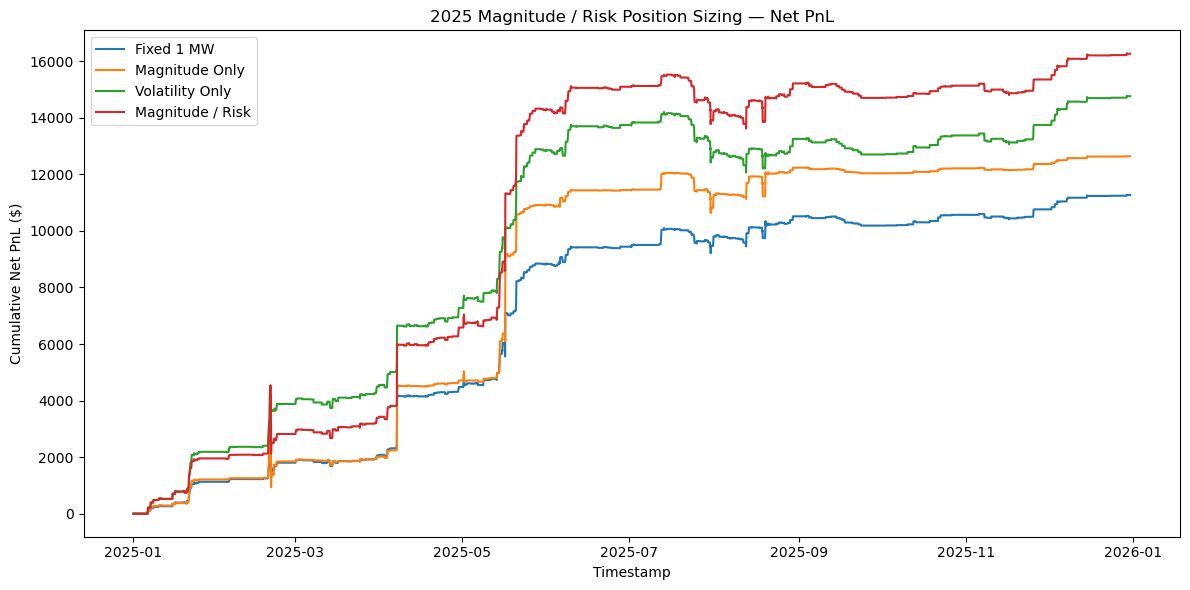

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2025 MAGNITUDE / RISK POSITION-SIZING COMPARISON
#
# Compares:
# 1. Fixed 1 MW
# 2. Predicted magnitude sizing
# 3. Inverse-volatility sizing
# 4. Predicted magnitude / volatility sizing
#
# All thresholds, volatility floors, and scaling constants
# are estimated from PRE-2025 training data only.
# ============================================================


# ------------------------------------------------------------
# 1. TRAINING PREDICTIONS
# ------------------------------------------------------------

pred_dir_train = model_dir.predict(X_train)
pred_vol_train = model_vol.predict(X_train)


# ------------------------------------------------------------
# 2. BUILD TRAINING DATAFRAME
# ------------------------------------------------------------

train_mag_2025 = train.copy().reset_index(drop=True)

train_mag_2025['pred_dir'] = pred_dir_train
train_mag_2025['pred_vol'] = pred_vol_train

train_mag_2025 = (
    train_mag_2025
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. BUILD 2025 TEST DATAFRAME
# ------------------------------------------------------------

test_mag_2025 = test.copy().reset_index(drop=True)

test_mag_2025['pred_dir'] = pred_dir
test_mag_2025['pred_vol'] = pred_vol

test_mag_2025 = (
    test_mag_2025
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. TRADE THRESHOLDS — TRAINING DATA ONLY
# ------------------------------------------------------------

vol_q = 0.90
dir_q = 0.70

magnitude_threshold = (
    train_mag_2025['pred_vol']
    .quantile(vol_q)
)

direction_threshold = (
    train_mag_2025['pred_dir']
    .abs()
    .quantile(dir_q)
)

print("Training magnitude threshold:", magnitude_threshold)
print("Training directional threshold:", direction_threshold)


# ------------------------------------------------------------
# 5. APPLY TRADE FILTER
# ------------------------------------------------------------

train_mag_2025['trade_flag'] = (
    (train_mag_2025['pred_vol'] > magnitude_threshold) &
    (train_mag_2025['pred_dir'].abs() > direction_threshold)
).astype(int)

test_mag_2025['trade_flag'] = (
    (test_mag_2025['pred_vol'] > magnitude_threshold) &
    (test_mag_2025['pred_dir'].abs() > direction_threshold)
).astype(int)


# ------------------------------------------------------------
# 6. VOLATILITY FLOOR — TRAINING DATA ONLY
# ------------------------------------------------------------

vol_floor = (
    train_mag_2025['spread_vol_24']
    .quantile(0.10)
)

train_mag_2025['risk_vol'] = (
    train_mag_2025['spread_vol_24']
    .clip(lower=vol_floor)
)

test_mag_2025['risk_vol'] = (
    test_mag_2025['spread_vol_24']
    .clip(lower=vol_floor)
)

print("Training volatility floor:", vol_floor)


# ============================================================
# 7. RAW SIZING SCORES
# ============================================================

# ------------------------------------------------------------
# A. MAGNITUDE ONLY
#
# Larger predicted absolute spread = larger position
# ------------------------------------------------------------

train_mag_2025['score_magnitude'] = (
    train_mag_2025['pred_vol']
)

test_mag_2025['score_magnitude'] = (
    test_mag_2025['pred_vol']
)


# ------------------------------------------------------------
# B. VOLATILITY ONLY
#
# Lower trailing realized volatility = larger position
# ------------------------------------------------------------

train_mag_2025['score_vol'] = (
    1 / train_mag_2025['risk_vol']
)

test_mag_2025['score_vol'] = (
    1 / test_mag_2025['risk_vol']
)


# ------------------------------------------------------------
# C. MAGNITUDE / RISK
#
# Predicted opportunity relative to trailing volatility
# ------------------------------------------------------------

train_mag_2025['score_mag_risk'] = (
    train_mag_2025['pred_vol']
    / train_mag_2025['risk_vol']
)

test_mag_2025['score_mag_risk'] = (
    test_mag_2025['pred_vol']
    / test_mag_2025['risk_vol']
)


# ============================================================
# 8. CALIBRATE POSITION-SIZE SCALE
#
# We choose a scale factor using TRAINING DATA ONLY so that
# average absolute MW among qualifying training trades is
# approximately 1 MW AFTER clipping.
# ============================================================

min_size = 0.25
max_size = 2.00
target_avg_mw = 1.00


def calibrate_scale(
    df,
    score_col,
    target_avg=1.0,
    min_size=0.25,
    max_size=2.0
):
    
    scores = df.loc[
        df['trade_flag'] == 1,
        score_col
    ].dropna()

    # Binary search for scale factor
    low = 0.000001
    high = 1000000.0

    for _ in range(100):
        mid = (low + high) / 2

        sizes = (
            scores * mid
        ).clip(
            lower=min_size,
            upper=max_size
        )

        avg_size = sizes.mean()

        if avg_size > target_avg:
            high = mid
        else:
            low = mid

    return (low + high) / 2


scale_magnitude = calibrate_scale(
    train_mag_2025,
    'score_magnitude'
)

scale_vol = calibrate_scale(
    train_mag_2025,
    'score_vol'
)

scale_mag_risk = calibrate_scale(
    train_mag_2025,
    'score_mag_risk'
)

print("\nTraining sizing scale factors:")
print("Magnitude:", scale_magnitude)
print("Volatility:", scale_vol)
print("Magnitude/Risk:", scale_mag_risk)


# ------------------------------------------------------------
# CHECK TRAINING AVERAGE MW
# ------------------------------------------------------------

for label, score_col, scale in [
    ('Magnitude', 'score_magnitude', scale_magnitude),
    ('Volatility', 'score_vol', scale_vol),
    ('Magnitude/Risk', 'score_mag_risk', scale_mag_risk)
]:

    qualifying_scores = train_mag_2025.loc[
        train_mag_2025['trade_flag'] == 1,
        score_col
    ]

    training_sizes = (
        qualifying_scores * scale
    ).clip(
        lower=min_size,
        upper=max_size
    )

    print(
        label,
        "training avg MW:",
        training_sizes.mean()
    )


# ============================================================
# 9. CREATE TEST-PERIOD POSITION SIZES
# ============================================================

test_mag_2025['size_magnitude'] = (
    test_mag_2025['score_magnitude']
    * scale_magnitude
).clip(
    lower=min_size,
    upper=max_size
)

test_mag_2025['size_vol'] = (
    test_mag_2025['score_vol']
    * scale_vol
).clip(
    lower=min_size,
    upper=max_size
)

test_mag_2025['size_mag_risk'] = (
    test_mag_2025['score_mag_risk']
    * scale_mag_risk
).clip(
    lower=min_size,
    upper=max_size
)


# ============================================================
# 10. CREATE POSITIONS
# ============================================================

direction = np.sign(
    test_mag_2025['pred_dir']
)

trade_flag = (
    test_mag_2025['trade_flag']
)


# Fixed
test_mag_2025['pos_fixed'] = (
    direction
    * trade_flag
)


# Magnitude only
test_mag_2025['pos_magnitude'] = (
    direction
    * test_mag_2025['size_magnitude']
    * trade_flag
)


# Volatility only
test_mag_2025['pos_vol'] = (
    direction
    * test_mag_2025['size_vol']
    * trade_flag
)


# Magnitude / Risk
test_mag_2025['pos_mag_risk'] = (
    direction
    * test_mag_2025['size_mag_risk']
    * trade_flag
)


# ============================================================
# 11. TRANSACTION COSTS + NET PNL
# ============================================================

cost_per_mwh = 1.0

strategies = {
    'Fixed 1 MW': 'pos_fixed',
    'Magnitude Only': 'pos_magnitude',
    'Volatility Only': 'pos_vol',
    'Magnitude / Risk': 'pos_mag_risk'
}


for strategy_name, pos_col in strategies.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    # Gross PnL
    test_mag_2025[f'pnl_gross_{short_name}'] = (
        test_mag_2025[pos_col]
        * test_mag_2025['target_1h']
    )

    # $1/MWh transaction cost
    test_mag_2025[f'cost_{short_name}'] = (
        cost_per_mwh
        * test_mag_2025[pos_col].abs()
    )

    # Net PnL
    test_mag_2025[f'pnl_net_{short_name}'] = (
        test_mag_2025[f'pnl_gross_{short_name}']
        - test_mag_2025[f'cost_{short_name}']
    )

    # Cumulative net PnL
    test_mag_2025[f'cum_pnl_{short_name}'] = (
        test_mag_2025[f'pnl_net_{short_name}']
        .cumsum()
    )


# ============================================================
# 12. SUMMARY FUNCTION
# ============================================================

def summarize_mag_strategy(
    pnl,
    pos,
    timestamps
):

    results = pd.DataFrame({
        'timestamp': pd.to_datetime(timestamps),
        'pnl': pnl,
        'pos': pos
    }).dropna()

    # Total + hourly stats
    total_pnl = results['pnl'].sum()
    mean_pnl = results['pnl'].mean()
    std_pnl = results['pnl'].std()

    hourly_sharpe = (
        mean_pnl / std_pnl
        if std_pnl > 0
        else np.nan
    )

    # Drawdown
    cumulative = results['pnl'].cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    max_drawdown = drawdown.min()

    # Daily PnL
    results['date'] = (
        results['timestamp'].dt.date
    )

    daily_pnl = (
        results
        .groupby('date')['pnl']
        .sum()
    )

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    daily_sharpe = (
        daily_mean / daily_std
        if daily_std > 0
        else np.nan
    )

    sharpe_365 = (
        daily_sharpe * np.sqrt(365)
    )

    sharpe_252 = (
        daily_sharpe * np.sqrt(252)
    )

    traded_positions = results.loc[
        results['pos'] != 0,
        'pos'
    ]

    return {
        'net_pnl_total': total_pnl,
        'mean_hourly_pnl': mean_pnl,
        'std_hourly_pnl': std_pnl,
        'hourly_sharpe': hourly_sharpe,
        'daily_sharpe': daily_sharpe,
        'annualized_sharpe_365': sharpe_365,
        'annualized_sharpe_252': sharpe_252,
        'trades': int(
            (results['pos'] != 0).sum()
        ),
        'avg_abs_mw': (
            traded_positions.abs().mean()
        ),
        'max_abs_mw': (
            traded_positions.abs().max()
        ),
        'max_drawdown': max_drawdown
    }


# ============================================================
# 13. RESULTS TABLE
# ============================================================

results_mag_2025 = {}

for strategy_name, pos_col in strategies.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    pnl_col = (
        f'pnl_net_{short_name}'
    )

    results_mag_2025[strategy_name] = (
        summarize_mag_strategy(
            test_mag_2025[pnl_col],
            test_mag_2025[pos_col],
            test_mag_2025['timestamp']
        )
    )


results_table_mag_2025 = (
    pd.DataFrame(results_mag_2025).T
)

print("\n============================================")
print("2025 MAGNITUDE / RISK SIZING COMPARISON")
print("============================================\n")

print(results_table_mag_2025)


# ============================================================
# 14. PLOT CUMULATIVE NET PNL
# ============================================================

plt.figure(figsize=(12, 6))

for strategy_name in strategies.keys():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    plt.plot(
        test_mag_2025['timestamp'],
        test_mag_2025[
            f'cum_pnl_{short_name}'
        ],
        label=strategy_name
    )

plt.title(
    '2025 Magnitude / Risk Position Sizing — Net PnL'
)

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net PnL ($)')
plt.legend()
plt.tight_layout()

plt.savefig(
    '2025 Magnitude Risk Position Sizing.png',
    dpi=300
)

plt.show()

Training magnitude threshold: 40.44268255468353
Training directional threshold: 10.979012828546331
Training volatility floor: 5.856542252964329

Training sizing scale factors:
Magnitude: 0.007753604302293802
Volatility: 58.85477528576426
Magnitude/Risk: 0.520427293778303
Magnitude training avg MW: 1.0
Volatility training avg MW: 1.0000000000000002
Magnitude/Risk training avg MW: 1.0

2024 MAGNITUDE / RISK SIZING COMPARISON

                  net_pnl_total  mean_hourly_pnl  std_hourly_pnl  \
Fixed 1 MW         12897.330000         1.468442       53.965865   
Magnitude Only     16846.951932         1.918132       79.056192   
Volatility Only    12413.909862         1.413402       49.758257   
Magnitude / Risk   18636.779345         2.121915       71.006619   

                  hourly_sharpe  daily_sharpe  annualized_sharpe_365  \
Fixed 1 MW             0.027211      0.117404               2.243003   
Magnitude Only         0.024263      0.101741               1.943762   
Volatility Only

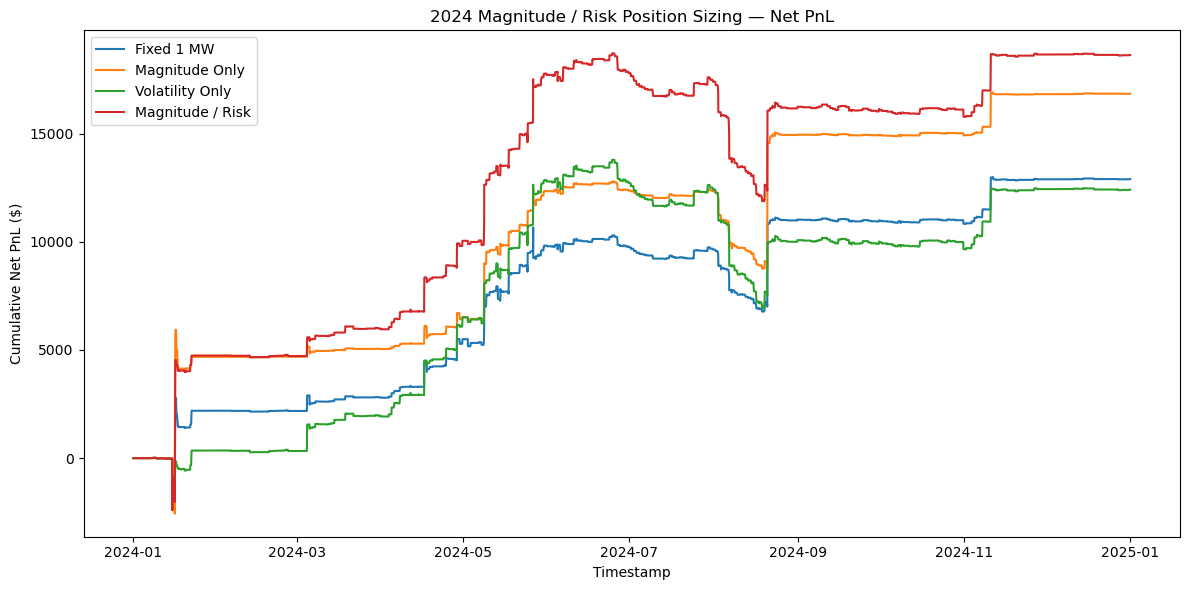

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2024 MAGNITUDE / RISK POSITION-SIZING COMPARISON
#
# Compares:
# 1. Fixed 1 MW
# 2. Predicted magnitude sizing
# 3. Inverse-volatility sizing
# 4. Predicted magnitude / volatility sizing
#
# All thresholds, volatility floors, and scaling constants
# are estimated from PRE-2024 training data only.
# ============================================================


# ------------------------------------------------------------
# 1. TRAINING PREDICTIONS
# ------------------------------------------------------------

pred_dir_train_2024 = model_dir_2024.predict(X_train_2024)
pred_vol_train_2024 = model_vol_2024.predict(X_train_2024)


# ------------------------------------------------------------
# 2. BUILD TRAINING DATAFRAME
# ------------------------------------------------------------

train_mag_2024 = train_2024.copy().reset_index(drop=True)

train_mag_2024['pred_dir'] = pred_dir_train_2024
train_mag_2024['pred_vol'] = pred_vol_train_2024

train_mag_2024 = (
    train_mag_2024
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. BUILD 2024 TEST DATAFRAME
# ------------------------------------------------------------

test_mag_2024 = test_2024.copy().reset_index(drop=True)

test_mag_2024['pred_dir'] = pred_dir_2024
test_mag_2024['pred_vol'] = pred_vol_2024

test_mag_2024 = (
    test_mag_2024
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. TRADE THRESHOLDS — PRE-2024 DATA ONLY
# ------------------------------------------------------------

vol_q = 0.90
dir_q = 0.70

magnitude_threshold_2024 = (
    train_mag_2024['pred_vol']
    .quantile(vol_q)
)

direction_threshold_2024 = (
    train_mag_2024['pred_dir']
    .abs()
    .quantile(dir_q)
)

print("Training magnitude threshold:", magnitude_threshold_2024)
print("Training directional threshold:", direction_threshold_2024)


# ------------------------------------------------------------
# 5. APPLY TRADE FILTER
# ------------------------------------------------------------

train_mag_2024['trade_flag'] = (
    (train_mag_2024['pred_vol'] > magnitude_threshold_2024) &
    (train_mag_2024['pred_dir'].abs() > direction_threshold_2024)
).astype(int)

test_mag_2024['trade_flag'] = (
    (test_mag_2024['pred_vol'] > magnitude_threshold_2024) &
    (test_mag_2024['pred_dir'].abs() > direction_threshold_2024)
).astype(int)


# ------------------------------------------------------------
# 6. VOLATILITY FLOOR — PRE-2024 DATA ONLY
# ------------------------------------------------------------

vol_floor_2024 = (
    train_mag_2024['spread_vol_24']
    .quantile(0.10)
)

train_mag_2024['risk_vol'] = (
    train_mag_2024['spread_vol_24']
    .clip(lower=vol_floor_2024)
)

test_mag_2024['risk_vol'] = (
    test_mag_2024['spread_vol_24']
    .clip(lower=vol_floor_2024)
)

print("Training volatility floor:", vol_floor_2024)


# ============================================================
# 7. RAW SIZING SCORES
# ============================================================

# A. MAGNITUDE ONLY
train_mag_2024['score_magnitude'] = (
    train_mag_2024['pred_vol']
)

test_mag_2024['score_magnitude'] = (
    test_mag_2024['pred_vol']
)


# B. VOLATILITY ONLY
train_mag_2024['score_vol'] = (
    1 / train_mag_2024['risk_vol']
)

test_mag_2024['score_vol'] = (
    1 / test_mag_2024['risk_vol']
)


# C. MAGNITUDE / RISK
train_mag_2024['score_mag_risk'] = (
    train_mag_2024['pred_vol']
    / train_mag_2024['risk_vol']
)

test_mag_2024['score_mag_risk'] = (
    test_mag_2024['pred_vol']
    / test_mag_2024['risk_vol']
)


# ============================================================
# 8. CALIBRATE SCALE TO 1 MW AVG ON TRAINING TRADES
# ============================================================

min_size = 0.25
max_size = 2.00
target_avg_mw = 1.00


def calibrate_scale(
    df,
    score_col,
    target_avg=1.0,
    min_size=0.25,
    max_size=2.0
):

    scores = df.loc[
        df['trade_flag'] == 1,
        score_col
    ].dropna()

    low = 0.000001
    high = 1000000.0

    for _ in range(100):
        mid = (low + high) / 2

        sizes = (
            scores * mid
        ).clip(
            lower=min_size,
            upper=max_size
        )

        avg_size = sizes.mean()

        if avg_size > target_avg:
            high = mid
        else:
            low = mid

    return (low + high) / 2


scale_magnitude_2024 = calibrate_scale(
    train_mag_2024,
    'score_magnitude'
)

scale_vol_2024 = calibrate_scale(
    train_mag_2024,
    'score_vol'
)

scale_mag_risk_2024 = calibrate_scale(
    train_mag_2024,
    'score_mag_risk'
)

print("\nTraining sizing scale factors:")
print("Magnitude:", scale_magnitude_2024)
print("Volatility:", scale_vol_2024)
print("Magnitude/Risk:", scale_mag_risk_2024)


# ------------------------------------------------------------
# 9. VERIFY TRAINING AVG MW
# ------------------------------------------------------------

for label, score_col, scale in [
    ('Magnitude', 'score_magnitude', scale_magnitude_2024),
    ('Volatility', 'score_vol', scale_vol_2024),
    ('Magnitude/Risk', 'score_mag_risk', scale_mag_risk_2024)
]:

    qualifying_scores = train_mag_2024.loc[
        train_mag_2024['trade_flag'] == 1,
        score_col
    ]

    training_sizes = (
        qualifying_scores * scale
    ).clip(
        lower=min_size,
        upper=max_size
    )

    print(
        label,
        "training avg MW:",
        training_sizes.mean()
    )


# ============================================================
# 10. CREATE TEST-PERIOD POSITION SIZES
# ============================================================

test_mag_2024['size_magnitude'] = (
    test_mag_2024['score_magnitude']
    * scale_magnitude_2024
).clip(
    lower=min_size,
    upper=max_size
)

test_mag_2024['size_vol'] = (
    test_mag_2024['score_vol']
    * scale_vol_2024
).clip(
    lower=min_size,
    upper=max_size
)

test_mag_2024['size_mag_risk'] = (
    test_mag_2024['score_mag_risk']
    * scale_mag_risk_2024
).clip(
    lower=min_size,
    upper=max_size
)


# ============================================================
# 11. POSITIONS
# ============================================================

direction_2024 = np.sign(
    test_mag_2024['pred_dir']
)

trade_flag_2024 = (
    test_mag_2024['trade_flag']
)


test_mag_2024['pos_fixed'] = (
    direction_2024
    * trade_flag_2024
)

test_mag_2024['pos_magnitude'] = (
    direction_2024
    * test_mag_2024['size_magnitude']
    * trade_flag_2024
)

test_mag_2024['pos_vol'] = (
    direction_2024
    * test_mag_2024['size_vol']
    * trade_flag_2024
)

test_mag_2024['pos_mag_risk'] = (
    direction_2024
    * test_mag_2024['size_mag_risk']
    * trade_flag_2024
)


# ============================================================
# 12. COSTS + NET PNL
# ============================================================

cost_per_mwh = 1.0

strategies_2024 = {
    'Fixed 1 MW': 'pos_fixed',
    'Magnitude Only': 'pos_magnitude',
    'Volatility Only': 'pos_vol',
    'Magnitude / Risk': 'pos_mag_risk'
}


for strategy_name, pos_col in strategies_2024.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    test_mag_2024[f'pnl_gross_{short_name}'] = (
        test_mag_2024[pos_col]
        * test_mag_2024['target_1h']
    )

    test_mag_2024[f'cost_{short_name}'] = (
        cost_per_mwh
        * test_mag_2024[pos_col].abs()
    )

    test_mag_2024[f'pnl_net_{short_name}'] = (
        test_mag_2024[f'pnl_gross_{short_name}']
        - test_mag_2024[f'cost_{short_name}']
    )

    test_mag_2024[f'cum_pnl_{short_name}'] = (
        test_mag_2024[f'pnl_net_{short_name}']
        .cumsum()
    )


# ============================================================
# 13. SUMMARY FUNCTION
# ============================================================

def summarize_mag_strategy_2024(
    pnl,
    pos,
    timestamps
):

    results = pd.DataFrame({
        'timestamp': pd.to_datetime(timestamps),
        'pnl': pnl,
        'pos': pos
    }).dropna()

    total_pnl = results['pnl'].sum()
    mean_pnl = results['pnl'].mean()
    std_pnl = results['pnl'].std()

    hourly_sharpe = (
        mean_pnl / std_pnl
        if std_pnl > 0
        else np.nan
    )

    cumulative = results['pnl'].cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    max_drawdown = drawdown.min()

    results['date'] = (
        results['timestamp'].dt.date
    )

    daily_pnl = (
        results
        .groupby('date')['pnl']
        .sum()
    )

    daily_mean = daily_pnl.mean()
    daily_std = daily_pnl.std()

    daily_sharpe = (
        daily_mean / daily_std
        if daily_std > 0
        else np.nan
    )

    sharpe_365 = (
        daily_sharpe * np.sqrt(365)
    )

    sharpe_252 = (
        daily_sharpe * np.sqrt(252)
    )

    traded_positions = results.loc[
        results['pos'] != 0,
        'pos'
    ]

    return {
        'net_pnl_total': total_pnl,
        'mean_hourly_pnl': mean_pnl,
        'std_hourly_pnl': std_pnl,
        'hourly_sharpe': hourly_sharpe,
        'daily_sharpe': daily_sharpe,
        'annualized_sharpe_365': sharpe_365,
        'annualized_sharpe_252': sharpe_252,
        'trades': int(
            (results['pos'] != 0).sum()
        ),
        'avg_abs_mw': (
            traded_positions.abs().mean()
        ),
        'max_abs_mw': (
            traded_positions.abs().max()
        ),
        'max_drawdown': max_drawdown
    }


# ============================================================
# 14. RESULTS TABLE
# ============================================================

results_mag_2024 = {}

for strategy_name, pos_col in strategies_2024.items():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    pnl_col = (
        f'pnl_net_{short_name}'
    )

    results_mag_2024[strategy_name] = (
        summarize_mag_strategy_2024(
            test_mag_2024[pnl_col],
            test_mag_2024[pos_col],
            test_mag_2024['timestamp']
        )
    )


results_table_mag_2024 = (
    pd.DataFrame(results_mag_2024).T
)

print("\n============================================")
print("2024 MAGNITUDE / RISK SIZING COMPARISON")
print("============================================\n")

print(results_table_mag_2024)


# ============================================================
# 15. PLOT
# ============================================================

plt.figure(figsize=(12, 6))

for strategy_name in strategies_2024.keys():

    short_name = (
        strategy_name
        .lower()
        .replace(' ', '_')
        .replace('/', 'to')
    )

    plt.plot(
        test_mag_2024['timestamp'],
        test_mag_2024[
            f'cum_pnl_{short_name}'
        ],
        label=strategy_name
    )

plt.title(
    '2024 Magnitude / Risk Position Sizing — Net PnL'
)

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net PnL ($)')
plt.legend()
plt.tight_layout()

plt.savefig(
    '2024 Magnitude Risk Position Sizing.png',
    dpi=300
)

plt.show()



2024: Volatility Regime
Regime  Trades  Hit Rate  Avg Net PnL / Trade  Median Net PnL / Trade  Total Net PnL  Trade PnL Std  PnL / Risk Ratio  Avg Actual |Spread|  Avg Predicted Magnitude
   Low     334  0.422156            -0.746018                -4.82625      -249.1700      43.099747         -0.017309            15.516662                85.495418
Medium     226  0.526549             4.325299                 0.22125       977.5175      66.664225          0.064882            34.860476                87.112089
  High     307  0.566775            39.638379                 1.70000     12168.9825     277.062139          0.143067           107.558070               162.187819


2025: Volatility Regime
Regime  Trades  Hit Rate  Avg Net PnL / Trade  Median Net PnL / Trade  Total Net PnL  Trade PnL Std  PnL / Risk Ratio  Avg Actual |Spread|  Avg Predicted Magnitude
   Low     136  0.389706            -3.503566                -5.64375      -476.4850      19.946039         -0.175652           

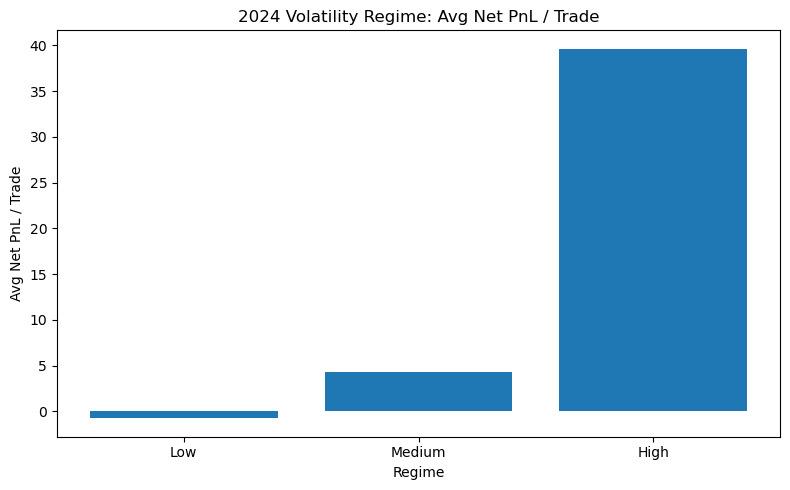

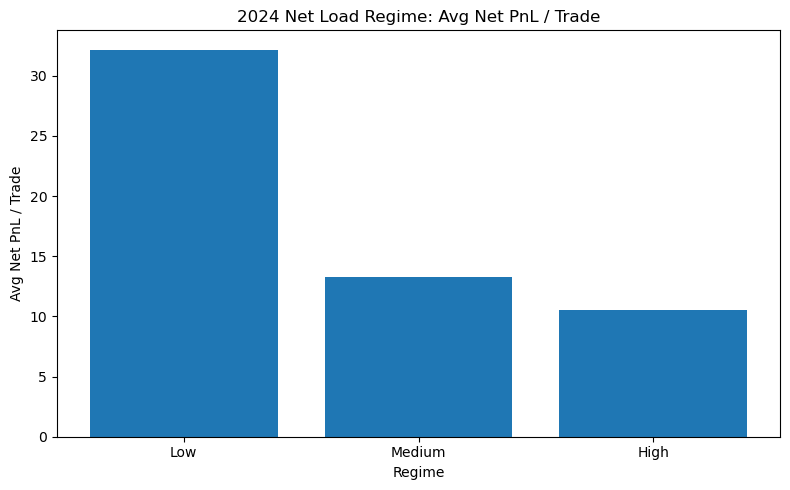

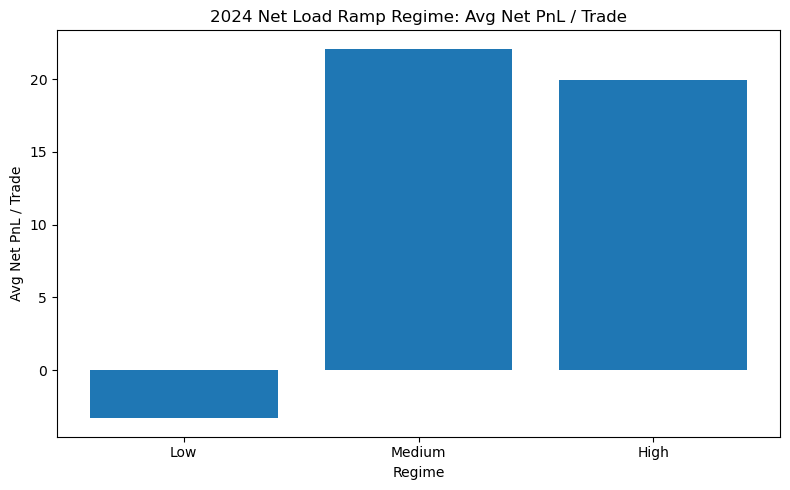

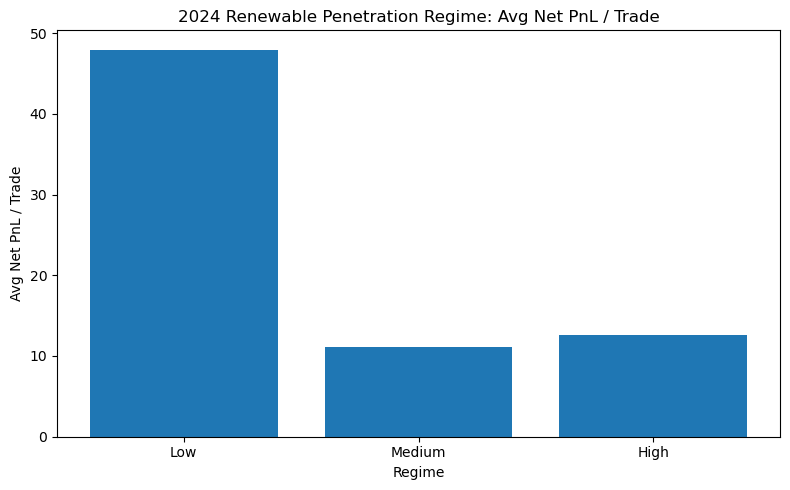

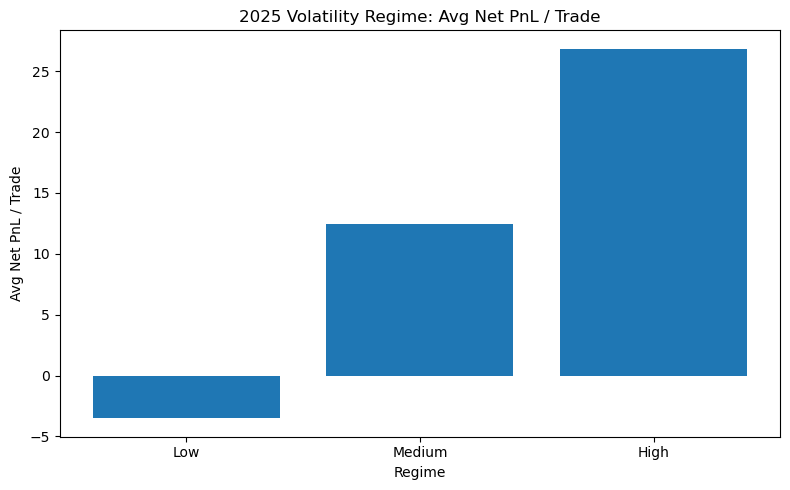

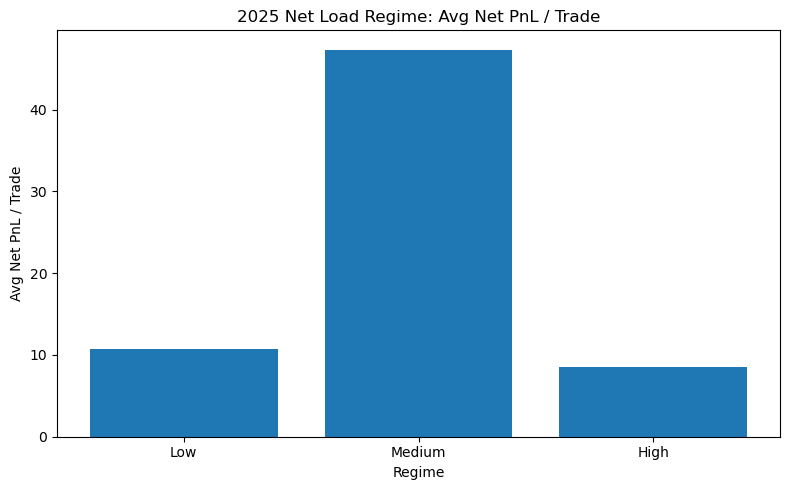

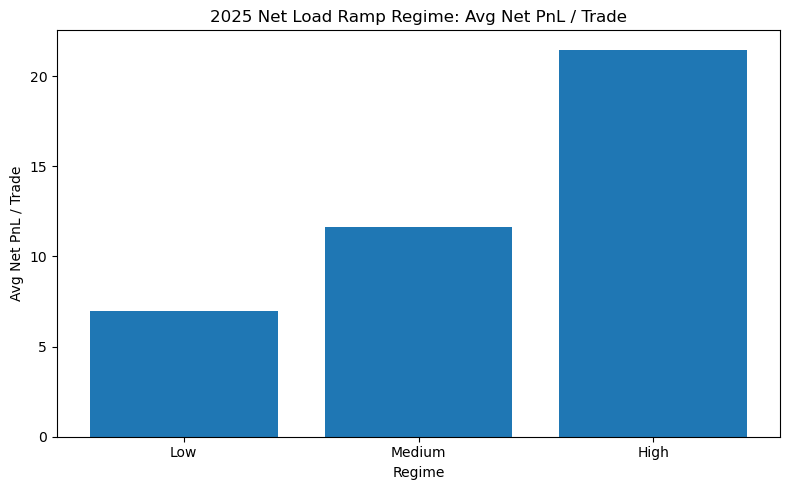

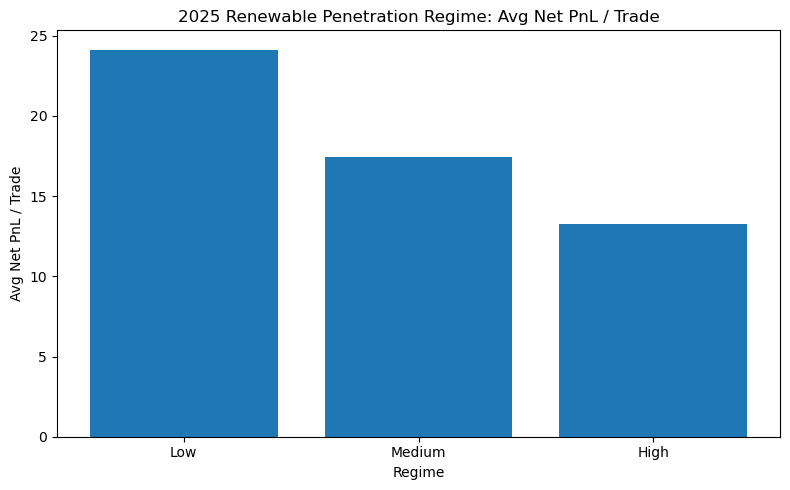

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# REGIME ANALYSIS — CLEAN FIXED-SIZE STRATEGY
#
# Years:
# 2024 = trained on pre-2024 data
# 2025 = trained on pre-2025 data
#
# Strategy:
# - Fixed +/- 1 MW
# - $1/MWh transaction cost
# - No dynamic sizing
# - No drawdown / rolling-loss overlay
#
# Important:
# - Trade thresholds come from TRAINING data only
# - Regime boundaries come from TRAINING data only
# ============================================================


# ============================================================
# 1. HELPER FUNCTION: BUILD CLEAN BACKTEST
# ============================================================

def build_clean_regime_backtest(
    train_df,
    test_df,
    pred_dir_train,
    pred_vol_train,
    pred_dir_test,
    pred_vol_test,
    cost_per_mwh=1.0
):
    
    # -----------------------------
    # BUILD TRAINING FRAME
    # -----------------------------
    
    train_bt = train_df.copy().reset_index(drop=True)
    
    train_bt['pred_dir'] = pred_dir_train
    train_bt['pred_vol'] = pred_vol_train
    
    # -----------------------------
    # BUILD TEST FRAME
    # -----------------------------
    
    test_bt = test_df.copy().reset_index(drop=True)
    
    test_bt['pred_dir'] = pred_dir_test
    test_bt['pred_vol'] = pred_vol_test
    
    train_bt = (
        train_bt
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )
    
    test_bt = (
        test_bt
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )
    
    
    # ========================================================
    # TRADE THRESHOLDS — TRAINING ONLY
    # ========================================================
    
    magnitude_threshold = (
        train_bt['pred_vol']
        .quantile(0.90)
    )
    
    direction_threshold = (
        train_bt['pred_dir']
        .abs()
        .quantile(0.70)
    )
    
    
    # Apply only to TEST YEAR
    
    test_bt['trade_flag'] = (
        (test_bt['pred_vol'] > magnitude_threshold) &
        (test_bt['pred_dir'].abs() > direction_threshold)
    ).astype(int)
    
    
    # ========================================================
    # FIXED +/- 1 MW POSITION
    # ========================================================
    
    test_bt['position'] = (
        np.sign(test_bt['pred_dir'])
        * test_bt['trade_flag']
    )
    
    
    # ========================================================
    # PNL
    # ========================================================
    
    test_bt['gross_pnl'] = (
        test_bt['position']
        * test_bt['target_1h']
    )
    
    test_bt['cost'] = (
        cost_per_mwh
        * test_bt['position'].abs()
    )
    
    test_bt['net_pnl'] = (
        test_bt['gross_pnl']
        - test_bt['cost']
    )
    
    
    # ========================================================
    # TRADE OUTCOME INFORMATION
    # ========================================================
    
    test_bt['correct_direction'] = (
        (
            np.sign(test_bt['pred_dir'])
            ==
            np.sign(test_bt['target_1h'])
        )
        &
        (test_bt['trade_flag'] == 1)
    ).astype(int)
    
    
    # ========================================================
    # EXTRA REGIME VARIABLES
    # ========================================================
    
    # Magnitude of net-load ramp
    train_bt['abs_net_load_ramp'] = (
        train_bt['net_load_diff1'].abs()
    )
    
    test_bt['abs_net_load_ramp'] = (
        test_bt['net_load_diff1'].abs()
    )
    
    
    # Renewable penetration
    # renewable generation as % of load
    
    train_bt['renewable_share'] = (
        train_bt['renewables']
        / train_bt['load']
    )
    
    test_bt['renewable_share'] = (
        test_bt['renewables']
        / test_bt['load']
    )
    
    
    # ========================================================
    # REGIME BOUNDARIES — TRAINING DATA ONLY
    #
    # Use terciles:
    # LOW = bottom third
    # MID = middle third
    # HIGH = top third
    # ========================================================
    
    regime_variables = {
        'Volatility Regime': 'spread_vol_24',
        'Net Load Regime': 'net_load',
        'Net Load Ramp Regime': 'abs_net_load_ramp',
        'Renewable Penetration Regime': 'renewable_share'
    }
    
    
    regime_cutoffs = {}
    
    
    for regime_name, variable in regime_variables.items():
        
        q33 = train_bt[variable].quantile(1/3)
        q67 = train_bt[variable].quantile(2/3)
        
        regime_cutoffs[regime_name] = {
            'variable': variable,
            'q33': q33,
            'q67': q67
        }
        
        
        # Assign TEST observations using TRAINING cutoffs
        
        test_bt[regime_name] = pd.cut(
            test_bt[variable],
            bins=[
                -np.inf,
                q33,
                q67,
                np.inf
            ],
            labels=[
                'Low',
                'Medium',
                'High'
            ]
        )
    
    
    return test_bt, regime_cutoffs


# ============================================================
# 2. TRAINING PREDICTIONS
# ============================================================

# 2025 models

pred_dir_train_2025 = model_dir.predict(X_train)
pred_vol_train_2025 = model_vol.predict(X_train)


# 2024 models

pred_dir_train_2024 = model_dir_2024.predict(X_train_2024)
pred_vol_train_2024 = model_vol_2024.predict(X_train_2024)


# ============================================================
# 3. BUILD CLEAN 2024 + 2025 REGIME BACKTESTS
# ============================================================

regime_bt_2024, cutoffs_2024 = (
    build_clean_regime_backtest(
        train_2024,
        test_2024,
        pred_dir_train_2024,
        pred_vol_train_2024,
        pred_dir_2024,
        pred_vol_2024
    )
)


regime_bt_2025, cutoffs_2025 = (
    build_clean_regime_backtest(
        train,
        test,
        pred_dir_train_2025,
        pred_vol_train_2025,
        pred_dir,
        pred_vol
    )
)


# ============================================================
# 4. REGIME SUMMARY FUNCTION
# ============================================================

def summarize_regime(
    df,
    regime_column
):
    
    rows = []
    
    
    for regime in ['Low', 'Medium', 'High']:
        
        subset = df[
            df[regime_column] == regime
        ].copy()
        
        
        # Only actual executed trades
        trades = subset[
            subset['trade_flag'] == 1
        ].copy()
        
        
        n_trades = len(trades)
        
        
        if n_trades == 0:
            continue
        
        
        hit_rate = (
            trades['correct_direction']
            .mean()
        )
        
        
        avg_net_pnl = (
            trades['net_pnl']
            .mean()
        )
        
        
        median_net_pnl = (
            trades['net_pnl']
            .median()
        )
        
        
        total_net_pnl = (
            trades['net_pnl']
            .sum()
        )
        
        
        std_trade_pnl = (
            trades['net_pnl']
            .std()
        )
        
        
        trade_sharpe = (
            avg_net_pnl / std_trade_pnl
            if std_trade_pnl > 0
            else np.nan
        )
        
        
        avg_actual_spread = (
            trades['target_1h']
            .abs()
            .mean()
        )
        
        
        avg_pred_magnitude = (
            trades['pred_vol']
            .mean()
        )
        
        
        rows.append({
            'Regime': regime,
            'Trades': n_trades,
            'Hit Rate': hit_rate,
            'Avg Net PnL / Trade': avg_net_pnl,
            'Median Net PnL / Trade': median_net_pnl,
            'Total Net PnL': total_net_pnl,
            'Trade PnL Std': std_trade_pnl,
            'PnL / Risk Ratio': trade_sharpe,
            'Avg Actual |Spread|': avg_actual_spread,
            'Avg Predicted Magnitude': avg_pred_magnitude
        })
    
    
    return pd.DataFrame(rows)


# ============================================================
# 5. RUN ALL REGIME ANALYSES
# ============================================================

regime_columns = [
    'Volatility Regime',
    'Net Load Regime',
    'Net Load Ramp Regime',
    'Renewable Penetration Regime'
]


results_2024 = {}
results_2025 = {}


for regime_col in regime_columns:
    
    results_2024[regime_col] = (
        summarize_regime(
            regime_bt_2024,
            regime_col
        )
    )
    
    results_2025[regime_col] = (
        summarize_regime(
            regime_bt_2025,
            regime_col
        )
    )


# ============================================================
# 6. PRINT RESULTS
# ============================================================

for regime_col in regime_columns:
    
    print("\n")
    print("=" * 70)
    print("2024:", regime_col)
    print("=" * 70)
    
    print(
        results_2024[regime_col]
        .to_string(index=False)
    )
    
    
    print("\n")
    print("=" * 70)
    print("2025:", regime_col)
    print("=" * 70)
    
    print(
        results_2025[regime_col]
        .to_string(index=False)
    )


# ============================================================
# 7. SIMPLE VISUALIZATION FUNCTION
# ============================================================

def plot_regime_metric(
    result_df,
    metric,
    year,
    regime_name
):
    
    plt.figure(figsize=(8, 5))
    
    plt.bar(
        result_df['Regime'],
        result_df[metric]
    )
    
    plt.title(
        f'{year} {regime_name}: {metric}'
    )
    
    plt.xlabel('Regime')
    plt.ylabel(metric)
    plt.tight_layout()
    
    filename = (
        f'{year}_{regime_name}_{metric}'
        .replace(' ', '_')
        .replace('/', '_')
        + '.png'
    )
    
    plt.savefig(
        filename,
        dpi=300
    )
    
    plt.show()


# ============================================================
# 8. CREATE MOST IMPORTANT CHARTS
# ============================================================

for year, result_dict in [
    (2024, results_2024),
    (2025, results_2025)
]:
    
    # Volatility: average PnL
    plot_regime_metric(
        result_dict['Volatility Regime'],
        'Avg Net PnL / Trade',
        year,
        'Volatility Regime'
    )
    
    
    # Net load: average PnL
    plot_regime_metric(
        result_dict['Net Load Regime'],
        'Avg Net PnL / Trade',
        year,
        'Net Load Regime'
    )
    
    
    # Ramp: average PnL
    plot_regime_metric(
        result_dict['Net Load Ramp Regime'],
        'Avg Net PnL / Trade',
        year,
        'Net Load Ramp Regime'
    )
    
    
    # Renewable penetration: average PnL
    plot_regime_metric(
        result_dict['Renewable Penetration Regime'],
        'Avg Net PnL / Trade',
        year,
        'Renewable Penetration Regime'
    )

In [26]:
import numpy as np
import pandas as pd

np.random.seed(42)

def bootstrap_regime_ci(
    df,
    regime_col='Volatility Regime',
    pnl_col='net_pnl',
    n_boot=10000,
    confidence=0.95
):

    results = []

    for regime in ['Low', 'Medium', 'High']:

        # Only executed trades in this regime
        x = (
            df.loc[
                (df[regime_col] == regime) &
                (df['trade_flag'] == 1),
                pnl_col
            ]
            .dropna()
            .values
        )

        boot_means = np.empty(n_boot)

        for i in range(n_boot):

            sample = np.random.choice(
                x,
                size=len(x),
                replace=True
            )

            boot_means[i] = sample.mean()

        alpha = 1 - confidence

        lower = np.quantile(
            boot_means,
            alpha / 2
        )

        upper = np.quantile(
            boot_means,
            1 - alpha / 2
        )

        results.append({
            'Regime': regime,
            'Trades': len(x),
            'Mean PnL / Trade': x.mean(),
            '95% CI Lower': lower,
            '95% CI Upper': upper
        })

    return pd.DataFrame(results)


print("2024 VOLATILITY REGIME — BOOTSTRAP 95% CI")

bootstrap_2024 = bootstrap_regime_ci(
    regime_bt_2024
)

print(
    bootstrap_2024.to_string(index=False)
)


print("\n2025 VOLATILITY REGIME — BOOTSTRAP 95% CI")

bootstrap_2025 = bootstrap_regime_ci(
    regime_bt_2025
)

print(
    bootstrap_2025.to_string(index=False)
)

2024 VOLATILITY REGIME — BOOTSTRAP 95% CI
Regime  Trades  Mean PnL / Trade  95% CI Lower  95% CI Upper
   Low     334         -0.746018     -4.500712      4.626187
Medium     226          4.325299     -4.341117     13.041197
  High     307         39.638379     10.492391     72.128538

2025 VOLATILITY REGIME — BOOTSTRAP 95% CI
Regime  Trades  Mean PnL / Trade  95% CI Lower  95% CI Upper
   Low     136         -3.503566     -6.938501     -0.184578
Medium     297         12.443207      8.325491     16.540116
  High     300         26.834150     12.593387     43.899558


In [27]:
def volatility_quality_analysis(
    df,
    regime_col='Volatility Regime'
):

    # Only executed trades
    x = df[
        df['trade_flag'] == 1
    ].copy()

    # Was our trade direction correct?
    x['correct_direction_check'] = (
        np.sign(x['position']) ==
        np.sign(x['target_1h'])
    ).astype(int)

    # Magnitude of actual DA/RT spread
    x['abs_spread_check'] = (
        x['target_1h'].abs()
    )

    # PnL relative to available spread magnitude
    x['normalized_pnl'] = np.where(
        x['abs_spread_check'] > 1e-6,
        x['net_pnl'] / x['abs_spread_check'],
        np.nan
    )

    results = (
        x.groupby(
            regime_col,
            observed=True
        )
        .agg(
            Trades=('net_pnl', 'size'),
            Hit_Rate=('correct_direction_check', 'mean'),
            Avg_Net_PnL=('net_pnl', 'mean'),
            Median_Net_PnL=('net_pnl', 'median'),
            Avg_Abs_Spread=('abs_spread_check', 'mean'),
            Normalized_PnL=('normalized_pnl', 'mean')
        )
        .reindex([
            'Low',
            'Medium',
            'High'
        ])
    )

    return results


print("2024 VOLATILITY QUALITY TEST")

quality_2024 = volatility_quality_analysis(
    regime_bt_2024
)

print(quality_2024)


print("\n2025 VOLATILITY QUALITY TEST")

quality_2025 = volatility_quality_analysis(
    regime_bt_2025
)

print(quality_2025)

2024 VOLATILITY QUALITY TEST
                   Trades  Hit_Rate  Avg_Net_PnL  Median_Net_PnL  \
Volatility Regime                                                  
Low                   334  0.422156    -0.746018        -4.82625   
Medium                226  0.526549     4.325299         0.22125   
High                  307  0.566775    39.638379         1.70000   

                   Avg_Abs_Spread  Normalized_PnL  
Volatility Regime                                  
Low                     15.516662       -0.585093  
Medium                  34.860476       -0.254111  
High                   107.558070       -0.250160  

2025 VOLATILITY QUALITY TEST
                   Trades  Hit_Rate  Avg_Net_PnL  Median_Net_PnL  \
Volatility Regime                                                  
Low                   136  0.389706    -3.503566        -5.64375   
Medium                297  0.686869    12.443207        12.63250   
High                  300  0.656667    26.834150         9.31250   
